# Tutorial . Electrocardiograma con la clase EM  . 
### Daniel Yedra Cázares, Erin C. McKiernan, Marco Arieli Herrera-Valdez,
### Facultad de Ciencias, UNAM


## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Clase EM ](#EM)

[2.1 Ejemplo de objeto EKG con sus métodos ](#CO)

[2.1.1 Picos R y QRS](#PR)

[2.1.2 Onda P](#EM2)

[2.1.3 Onda T](#Der)


## Introducción

El objetivo de este tutorial es emplear la clase de Electromiograma (EM) para el análisis específico de un Electrocardiograma (EKG). Para ello, utilizaremos el atributo tipo, el cual nos permitirá integrar métodos exclusivos para el estudio del EKG. A lo largo del tutorial, se presentarán ejemplos básicos de su uso.

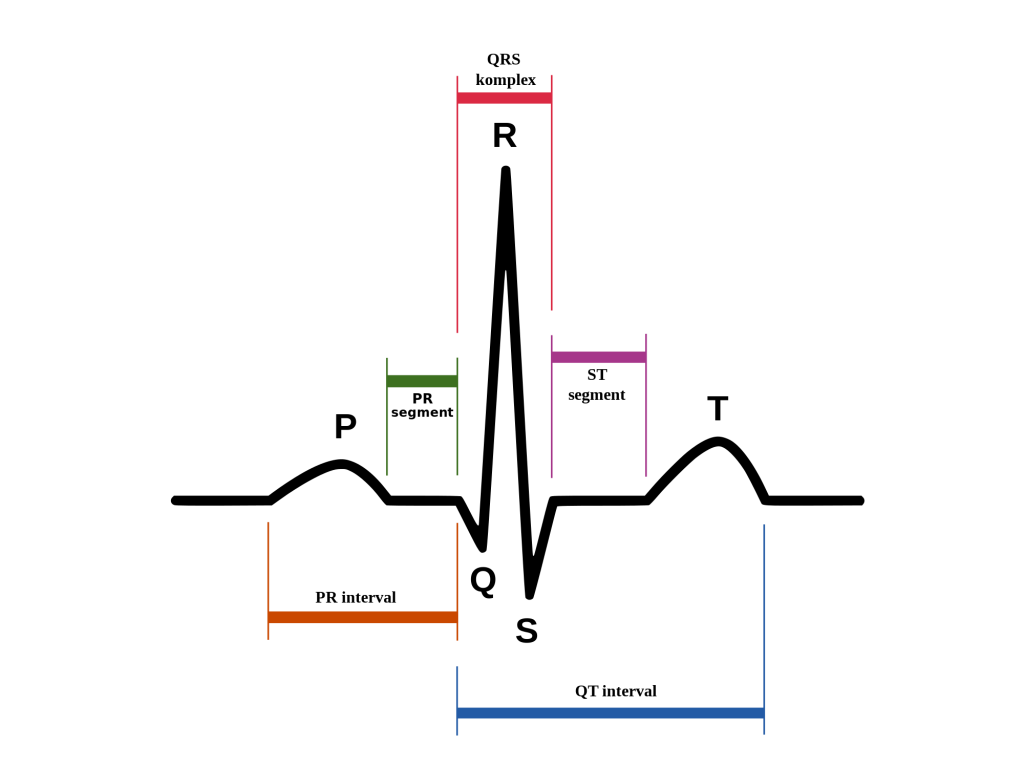

## Inicialización del Notebook

Primero prepararemos el entorno adecuado para el notebook

In [1]:
# Librerias
import numpy as np
import random as rd
import wave
import sys
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy.signal import butter, lfilter, filtfilt #fFiltrado de datos
from statistics import stdev
import scipy.stats as scs 
sys.path.insert(1, r'./../functions') 

# Gráficas
%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 16 
plt.rcParams['axes.titlesize'] = 18 
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 1.4 

## Clase EM


In [2]:
class EM: #Creamos la Clase de ECG
    
    def __init__(self, archivo=None, señal=None, tasa_muestra=None,tipo="EMG"): #Como crear un objeto de esta clase
        self.tipo = tipo  # Se añade un atributo para el tipo de electromiograma
        if archivo:
            # Si se pasa un archivo, cargarlo
            self.cargar_archivo(archivo)
        elif señal is not None and tasa_muestra is not None:
            # Si se pasa directamente la señal y la frecuencia de muestreo
            self.señal= señal
            self.tasa_muestra = tasa_muestra
            self.vector_tiempo = self.crear_vector_tiempo()
        else:
            raise ValueError("Debes proporcionar un archivo o la señal y frecuencia de muestreo.")
    
    def cargar_archivo(self, archivo):
        with wave.open(archivo, 'rb') as muestra:
            # Extraer el número de canales, la tasa de muestreo y los datos
            num_canales =  muestra.getnchannels()  # Número de canales
            N = muestra.getnframes()  # Número de frames
            self.tasa_muestra = muestra.getframerate()  # Tasa de muestreo

            # Extraer datos de la grabación .wav
            dstr = muestra.readframes(N * num_canales)
            self.señal = np.frombuffer(dstr, np.int16) #Lo que era waveData antes

            # Crear el vector de tiempo basado en la señal y la frecuencia de muestreo
            self.vector_tiempo = self.crear_vector_tiempo()

            # Imprimir información relevante
            print(f'El registro tiene {num_canales} canal(es).')
            print(f'La frecuencia de muestreo de la grabación es {self.tasa_muestra} Hz.')

    def crear_vector_tiempo(self):
        return np.linspace(0, len(self.señal) / self.tasa_muestra, num=len(self.señal))

    def set_tipo(self, tipo):
    
        self.tipo = tipo

    def get_tipo(self):
        
        return self.tipo

######### Métodos Generales

    def visualizar(self,xmin,xmax):
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))  # Tamaño más compacto y elegante
        
        # Graficar los datos
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')

        # Añadir título y etiquetas
        ax1.set_title('Datos del Registro', fontsize=22, fontweight='bold', color='darkblue')  # Título en negrita y azul
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')  # Eje X con color
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')  # Eje Y con color

        # Ajustar los límites según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')  # Mejorar tamaño y color de los ticks

        # Agregar una cuadrícula (grid) con un estilo suave
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')

        # Mostrar leyenda con los límites del eje x
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        # Mostrar la gráfica
        plt.tight_layout()  # Ajustar el diseño automáticamente para que no se corten los elementos
        plt.show()
        
    def Señal_filtrada_Bandpass(self,low_cutoff,high_cutoff):

        b, a = butter(2, [low_cutoff / (self.tasa_muestra / 2), high_cutoff / (self.tasa_muestra / 2)], btype='bandpass')
        Señal_bandpass = filtfilt(b, a, self.señal)
    
        return Señal_bandpass
        
    def visualizar_filtrada(self, xmin, xmax, low_cutoff, high_cutoff):
        # Obtener la señal filtrada
        señal_filtrada = self.Señal_filtrada_Bandpass(low_cutoff, high_cutoff)
        
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Graficar la señal cruda (con opacidad reducida) y la señal filtrada
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM Cruda', alpha=0.5)
        ax1.plot(self.vector_tiempo, señal_filtrada, color='darkred', linewidth=2, label='Señal EM Filtrada')
        
        # Añadir título y etiquetas
        ax1.set_title('Datos Crudos vs. Filtrado usando BP', fontsize=22, fontweight='bold', color='darkblue')
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')

        # Ajustar los límites del eje x según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        plt.tight_layout()
        plt.show()
        
    def aproxDer(self): 
        V = np.array(self.señal)  # Convertimos los datos a un array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 2:
            return np.zeros(N)  # Si hay menos de 2 elementos, no se puede derivar
    
        derivadas = np.zeros(N)  # Inicializamos un array del mismo tamaño
    
        if N > 2:
            # Derivada central para los puntos intermedios
            derivadas[1:-1] = (V[2:] - V[:-2]) / (2 * DT)
    
        # Derivada hacia adelante en el primer punto
        derivadas[0] = (V[1] - V[0]) / DT
    
        # Derivada hacia atrás en el último punto
        derivadas[-1] = (V[-1] - V[-2]) / DT

        return derivadas
        
    def aprox_2Der(self):

        V = np.array(self.señal)  # Convertir a array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 3:
            return np.zeros(N)  # No es posible calcular la segunda derivada con menos de 3 puntos
    
        derivadas2 = np.zeros(N)
    
        # Derivada central para puntos intermedios:
        # f''(x) ≈ (f(x+DT) - 2 f(x) + f(x-DT)) / DT²
        derivadas2[1:-1] = (V[2:] - 2 * V[1:-1] + V[:-2]) / (DT ** 2)
    
        # Para el primer y último punto usamos aproximaciones hacia adelante y hacia atrás:
        derivadas2[0] = (V[2] - 2 * V[1] + V[0]) / (DT ** 2)
        derivadas2[-1] = (V[-1] - 2 * V[-2] + V[-3]) / (DT ** 2)
    
        return derivadas2
    
    def visualizar_histograma(self, bins=50, color='skyblue', alpha=0.7, mostrar_kde=False):

        plt.figure(figsize=(10, 6))

        # Graficar el histograma con la opción de mostrar o no la KDE
        sns.histplot(self.señal, bins=bins, color=color, alpha=alpha, kde=mostrar_kde)

        plt.title('Histograma de la Señal', fontsize=22)
        plt.xlabel('Voltaje ($\mu$V)', fontsize=16)
        plt.ylabel('Frecuencia', fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')

        plt.tight_layout()
        plt.show()
        
    def Descrip_est(self):
        # Usar scipy.stats.describe para obtener el resumen estadístico de la señal
        stats = scs.describe(self.señal)
        
        # Desglosar los valores obtenidos
        nobs = stats.nobs          # Número de observaciones
        minmax = stats.minmax      # Mínimo y máximo de la señal
        mean = float(stats.mean)   # Convertir a tipo float
        variance = float(stats.variance)  # Convertir a tipo float
        skewness = float(stats.skewness)  # Convertir a tipo float
        kurtosis = float(stats.kurtosis)  # Convertir a tipo float
        
        # Mostrar los resultados de manera limpia
        print(f"Resumen Estadístico de la Señal EM:")
        print(f"  - Número de observaciones: {nobs}")
        print(f"  - Mínimo y máximo: {minmax}")
        print(f"  - Media: {mean:.4f}")  # Mostrar con 4 decimales
        print(f"  - Varianza: {variance:.4f}")  # Mostrar con 4 decimales
        print(f"  - Asimetría: {skewness:.4f}")  # Mostrar con 4 decimales
        print(f"  - Curtosis: {kurtosis:.4f}")  # Mostrar con 4 decimales

    # Método para discriminar por amplitud
    def discriminar_por_amplitud(self, umbral=400):
        # Crear un DataFrame con la señal y su tiempo
        df = pd.DataFrame({'Tiempo': self.vector_tiempo, 'Amplitud': self.señal})
        
        # Filtrar el DataFrame por amplitudes mayores al umbral
        filtered = df[df["Amplitud"] > umbral]
        
        # Mostrar la gráfica de las amplitudes mayores al umbral
        plt.figure(figsize=(12, 6))
        plt.plot(filtered['Tiempo'], filtered['Amplitud'], color='dodgerblue', linewidth=1.5)
        plt.title(f'Señal Filtrada por Amplitud > {umbral} $\mu$V', fontsize=22, fontweight='bold', color='darkblue')
        plt.xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        plt.ylabel('Amplitud ($\mu$V)', fontsize=16, color='darkgreen')
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()
        
        return filtered  # Devuelve el DataFrame filtrado

    # Método para dividir la señal en ventanas de tiempo
    def ventana_1_canal(self, x, npoints):
        single_chan_wind = []
        tot_points = len(x)  # Número total de puntos en la serie
        L = npoints

        nwind = tot_points // npoints  # Número de ventanas

        for h in range(0, nwind):
            t = x[h * L:L * (1 + h)]  # Separar en ventanas
            single_chan_wind.append(t)  # Guardar las ventanas

        return single_chan_wind

    # Método para calcular la varianza en cada ventana de tiempo
    def varianza_ventana_1_canal(self, x, npoints):
        tot_points = len(x)  # Número total de puntos
        nwind = tot_points // npoints  # Número de ventanas
        wind_x = self.ventana_1_canal(x, npoints)  # Llamada a la función para obtener las ventanas
        
        # Calcular la varianza de cada ventana
        v_single_chan_wind = [np.var(wind_x[w]) for w in range(0, nwind)]
        
        return v_single_chan_wind

    # Método para visualizar la varianza de la señal en ventanas de tiempo
    def visualizar_varianza(self, npoints=50000):
        # Normalizar la varianza para una mejor visualización
        varianza = self.varianza_ventana_1_canal(self.señal, npoints)
        varianza_normalizada = np.array(varianza) / max(varianza)

        # Crear la figura
        plt.figure(figsize=(20, 5), dpi=100)
        plt.title('Varianza del EM en ventanas de tiempo')
        plt.xlabel('Ventana de tiempo')
        plt.ylabel('Varianza')

        # Graficar la varianza normalizada
        plt.plot(varianza_normalizada)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()    

    def detecta_maximos_locales(self, threshold_ratio=0.7):
    # If not all the R peaks are detected, lower the threshold_ratio
    # If components that are not R peaks (like T waves) are detected, higher the threshold_ratio

        if len(self.vector_tiempo) != len(self.señal): #Raises an error if the two arrays have different lengths
            raise Exception("The two arrays have different lengths.")
    
        interval = max(self.señal) - min(self.señal)
        threshold = threshold_ratio*interval + min(self.señal)
        maxima = []
        maxima_indices = []
        mxs_indices = []
        banner = False
    
        for i in range(0, len(self.señal)):
            
            if self.señal[i] >= threshold:#If a threshold value is surpassed,
                # the indices and values are saved 
                banner = True
                maxima_indices.append(i)
                maxima.append(self.señal[i])
            
            elif banner == True and self.señal[i] < threshold: #If the threshold value is crossed
                # the index of the maximum value in the original array is saved
                index_local_max = maxima.index(max(maxima))
                mxs_indices.append(maxima_indices[index_local_max])
                maxima = []
                maxima_indices = []
                banner = False     

        return mxs_indices
    
    def cortar_segmento(self, t_inicio, t_fin):
 
        if t_inicio < 0 or t_fin > self.vector_tiempo[-1]:
            raise ValueError("Los tiempos de inicio o fin están fuera del rango de la señal.")
    
        # Encontramos los índices correspondientes a los tiempos de inicio y fin
        idx_inicio = np.searchsorted(self.vector_tiempo, t_inicio)
        idx_fin = np.searchsorted(self.vector_tiempo, t_fin)
    
        # Cortamos la señal y el vector de tiempo
        segmento = self.señal[idx_inicio:idx_fin]
        vector_tiempo_segmento = self.vector_tiempo[idx_inicio:idx_fin]
    
        # Creamos un nuevo objeto ECG con el segmento y su vector de tiempo
        nuevo_ecg = EM(señal=segmento, tasa_muestra=self.tasa_muestra)
        nuevo_ecg.vector_tiempo = vector_tiempo_segmento  # Actualizamos el vector de tiempo

        return nuevo_ecg
        

#########################  Métodos para EKG 

    ##Picos R
    def PicosR(self,T):

        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None
        
        print('Recuerda usar un segmento del registro')
        mxs_indices = self.detecta_maximos_locales(threshold_ratio=T)
        plt.figure(figsize=(18,6))
        plt.xlabel(r'Tiempo (s)')
        plt.ylabel(r'Voltaje ($\mu$V)')
        plt.xlim(min(self.vector_tiempo),max(self.vector_tiempo))
        plt.plot(self.vector_tiempo, self.señal)
        plt.scatter(self.vector_tiempo[mxs_indices], self.señal[mxs_indices], color='r')
        plt.title('Picos R del segmento del Registro')
        plt.show()

        return mxs_indices

    def LPM_FC(self,mxs_indices):

        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None
        if len(mxs_indices) < 2:
            print("No hay suficientes picos para calcular la frecuencia cardiaca.")
            return None

        mean_bpm = 60*(len(mxs_indices)/(self.vector_tiempo[-1]-self.vector_tiempo[0])) 
        print("Latidos por minuto:", mean_bpm)
        
        heart_rate = [(60/(self.vector_tiempo[mxs_indices[i+1]]-self.vector_tiempo[mxs_indices[i]])) for i in range(0, len(mxs_indices)-1)]
        time = self.vector_tiempo[mxs_indices]

        mean_vec = [mean_bpm for i in range(0, len(time)-1)]
        std_vec_plus = [mean_bpm+stdev(heart_rate) for i in range(0, len(time)-1)]
        std_vec_minus = [mean_bpm-stdev(heart_rate) for i in range(0, len(time)-1)]

        plt.fill_between(time[1:], std_vec_minus, std_vec_plus, facecolor="red",
                 label = "Desviación Estandar", color='red', alpha=0.4)
        plt.plot(time[1:], mean_vec, c="r", label = "Promedio de FC")
        plt.plot(time[1:], heart_rate, markersize=5, marker = "o", label="FC")
        plt.ylim((0, 140))
        plt.title("Frecuencia Cardiaca")
        plt.xlabel(r'Número de ciclos ECG')
        plt.ylabel(r'Tiempo ($s$)')
        plt.legend()
        plt.show()

        return[mean_bpm,heart_rate]

    ##Intervalos RR
    def Intervalos_RR(self,mxs_indices):

        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None

        def R_intervals(time_indices):
            length = len(time_indices)
            intervals = np.zeros(length-1)
    
            for i in range(0, length-1):
                intervals[i] = time_indices[i+1]-time_indices[i]
    
            return intervals
        

        xx = R_intervals(self.vector_tiempo[mxs_indices])
        mean_rr = np.mean(xx)
        print("Promedio del intervalo R-R : ",mean_rr)

        time = self.vector_tiempo[mxs_indices]

        mean_vec = [mean_rr for i in range(0, len(time)-1)]
        std_vec_plus = [mean_rr+stdev(xx) for i in range(0, len(time)-1)]
        std_vec_minus = [mean_rr-stdev(xx) for i in range(0, len(time)-1)]

        plt.fill_between(time[1:], std_vec_minus, std_vec_plus, facecolor="red",
                 label = "Desviación Estandar", color='red', alpha=0.4)
        plt.plot(time[1:], mean_vec, c="r", label = "Promedio FC")
        plt.plot(time[1:], xx, markersize=5, marker = "o", label="FC")
        plt.ylim((0, 1.3))
        plt.title("Intervalos R-R")
        plt.xlabel(r'Número de ciclos ECG')
        plt.ylabel(r'Tiempo ($s$)')
        plt.legend()
        plt.show()

        return [xx,mean_rr]

    def Prueba_FCRR(self,xx,mxs_indices,heart_rate):

        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None

        test = [60/xx[i] for i in range(0, len(xx))]

        time = self.vector_tiempo[mxs_indices]

        plt.plot(time[1:], test, markersize=10, marker = "o", label="R-R a FC", c = "blue")
        plt.plot(time[1:], heart_rate, markersize=5, marker = "o", label="FC", c="red")

        plt.ylim((0, max(test)+5))
        plt.title("Probando FC y los intervalos R-R ")
        plt.xlabel(r'Número de ciclos ECG')
        plt.ylabel(r'Tiempo ($s$)')
        plt.legend()
        plt.show()

    #######Complejo QRS

    def QRS(self,mxs_indices):

        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None
            
        mins_try = []
        i=0

        for R_peak_i in mxs_indices:
            left_interval = self.señal[R_peak_i-700:R_peak_i]
            right_interval = self.señal[R_peak_i:R_peak_i+700]
    
            mins_try.append(R_peak_i - 700 + (list(left_interval).index(min(left_interval))) )
            mins_try.append(R_peak_i + (list(right_interval).index(min(right_interval))) )

        # Plotting
        plt.figure(figsize=(18,6))
        plt.xlabel(r'Tiempo (s)')
        plt.ylabel(r'Voltaje ($\mu$V)')
        plt.xlim(min(self.vector_tiempo),max(self.vector_tiempo))
        plt.plot(self.vector_tiempo, self.señal)
        plt.scatter(self.vector_tiempo[mxs_indices], self.señal[mxs_indices], color='r')
        plt.scatter(self.vector_tiempo[mins_try], self.señal[mins_try], color='k')
        plt.show()

        return mins_try

    def Tamaño_QRS(self,mxs_indices,mins_try):

        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None
        
        qrs_length = np.zeros(len(mxs_indices))

        time = self.vector_tiempo[mxs_indices]

        for i in range(0, len(mxs_indices)):
            qrs_length[i] = self.vector_tiempo[mins_try[i*2 + 1]] - self.vector_tiempo[mins_try[i*2]]
    
        mean_qrs = np.mean(qrs_length)
        print("El promedio en segundos del complejo QRS es: ",mean_qrs)

        mean_vec = [mean_qrs for i in range(0, len(qrs_length))]
        std_vec_plus = [mean_qrs+stdev(qrs_length) for i in range(0, len(qrs_length))]
        std_vec_minus = [mean_qrs-stdev(qrs_length) for i in range(0, len(qrs_length))]

        
        plt.fill_between(time, std_vec_minus, std_vec_plus, facecolor="red",
                 label = "Desviación Estandar", color='red', alpha=0.4)
        plt.plot(time, mean_vec, c="r", label = "Promedio de la frecuencia QRS ")
        plt.plot(time, qrs_length, markersize=5, marker = "o", label="Tamaño de QRS")
        plt.ylim((0, max(qrs_length)+0.01))
        plt.title("Tamaño QRS")
        plt.xlabel(r'Número de ciclos ECG')
        plt.ylabel(r'Tiempo ($s$)')
        plt.legend()
        plt.show()

        return qrs_length

    ### Onda P

    def P_wave(self, mxs_indices, mins_try, nn=3000, VD=200):  # 0.3 segundos
        if self.tipo != "EKG":
            print("Este método solo está disponible para señales EKG.")
            return None

        p_wave_begin = []
        interval_der = VD  # ventana para obtener la derivada
        time_derivative_vec = []

        # Asegúrate de que mins_try y mxs_indices están definidos correctamente antes de este bucle
        for mxs_i in range(0, len(mxs_indices)):
            for i in range(0, nn - 500):  # Ajustamos el límite para evitar errores de índice
                index = mins_try[mxs_i * 2] - nn + i
                if index + interval_der >= len(self.señal) or index < 0:
                    continue  # Evitamos errores de índice fuera de rango

                # Cálculo de la derivada en la ventana de tiempo especificada
                aux = (self.señal[index + interval_der] - self.señal[index]) / (self.vector_tiempo[index + interval_der] - self.vector_tiempo[index])
                time_derivative_vec.append(aux)

               # if i % 500 == 0:  # Imprimir cada 500 iteraciones
                   # print(f"Derivada en índice {index}: {aux}")

                # Umbral de derivada
                threshold = max(time_derivative_vec) * 0.1  # 10% del valor máximo de la derivada
                if aux > threshold:
                    p_wave_begin.append(index)
                    break  # Salimos del bucle en cuanto detectamos el comienzo de la onda P

        # Buscar el final de la onda P
        p_wave_end = []
        for p_wave_i in p_wave_begin:
            truth = False
            index = 200
            while truth == False:
                if self.señal[p_wave_i + index] <= self.señal[p_wave_i] and self.señal[p_wave_i] > self.señal[p_wave_i + index + 1]:
                    p_wave_end.append(p_wave_i + index)
                    truth = True
                index += 1
                if index > len(self.señal):  # Evitar bucles infinitos
                    break

        return [p_wave_begin, p_wave_end]


    def Tamaño_Pwave(self,p_wave_begin, p_wave_end,mxs_indices):
        
        if len(p_wave_begin) != len(p_wave_end):
            print("El tamaño de los arrays de inicio y final son diferentes!")

        time = self.vector_tiempo[mxs_indices]
    
        p_wave_time = np.zeros(len(p_wave_begin)-1)
        for i in range(1, len(p_wave_begin)):
            p_wave_time[i-1] = self.vector_tiempo[p_wave_end[i]] - self.vector_tiempo[p_wave_begin[i]]
    
        mean_p_wave = np.mean(p_wave_time)
        print("Promedio en segundos de la P-wave: ",mean_p_wave)

        mean_vec = [mean_p_wave for i in range(0, len(time)-1)]
        std_vec_plus = [mean_p_wave+stdev(p_wave_time) for i in range(0, len(time)-1)]
        std_vec_minus = [mean_p_wave-stdev(p_wave_time) for i in range(0, len(time)-1)]

        plt.fill_between(time[1:], std_vec_minus, std_vec_plus, facecolor="red",
                 label = "Desviación Estandar", color='red', alpha=0.4)
        plt.plot(time[1:], mean_vec, c="r", label = "Promedio de la frecuencia")
        plt.plot(time[1:], p_wave_time, markersize=5, marker = "o", label="Tamaño de P-wave")
        plt.ylim((0, max(p_wave_time)+0.01))
        plt.title("Tamaño de la P-wave")
        plt.xlabel(r'Número de ciclos ECG')
        plt.ylabel(r'Tiempo ($s$)')
        plt.legend()
        plt.show()

    ##### Onda T

    def T_wave(self, mxs_indices, mins_try, nni, nnf, VDI=200, VDF=100):
        t_wave_begin = []
        interval_der = VDI  # ventana para derivada inicial
        time_derivative_vec = []

        for mxs_i in range(len(mxs_indices)):
            try:
                base_index = mins_try[mxs_i * 2][0] if isinstance(mins_try[mxs_i * 2], (list, tuple, np.ndarray)) else mins_try[mxs_i * 2]
            except IndexError:
                continue  # por si se sale del rango

            for i in range(nni - 500):
                index = base_index + nni + i
                if index + interval_der >= len(self.señal):
                    continue

                aux = (self.señal[index + interval_der] - self.señal[index]) / (
                    self.vector_tiempo[index + interval_der] - self.vector_tiempo[index]
                )
                time_derivative_vec.append(aux)

                if aux > 25000:  # Ajusta este umbral según la señal
                    t_wave_begin.append(index)
                    break

        t_wave_end = []
        interval_der = VDF  # ventana para derivada final
        time_derivative_vec = [0]  # reiniciar

        for mxs_i in range(len(mxs_indices)):
            try:
                base_index = mins_try[mxs_i * 2][0] if isinstance(mins_try[mxs_i * 2], (list, tuple, np.ndarray)) else mins_try[mxs_i * 2]
            except IndexError:
                continue

            for i in range(nnf - 500):
                index = base_index + nnf + i
                if index + interval_der >= len(self.señal):
                    continue

                aux = (self.señal[index + interval_der] - self.señal[index]) / (
                    self.vector_tiempo[index + interval_der] - self.vector_tiempo[index]
                )
                time_derivative_vec.append(aux)

                if i > 0 and time_derivative_vec[i] > 0 and time_derivative_vec[i - 1] < 0:
                    t_wave_end.append(index)
                    break

        return [t_wave_begin, t_wave_end]

    def Tamaño_Twave(self,mxs_indices,t_wave_begin, t_wave_end):
        # Intervalos T
        if len(t_wave_begin) != len(t_wave_end):
            print("El tamaño de los arrays de inicio y final son diferentes!")

        time = self.vector_tiempo[mxs_indices]
        t_wave_time = np.zeros(len(t_wave_begin)-1)
        for i in range(1, len(t_wave_begin)):
            t_wave_time[i-1] = self.vector_tiempo[t_wave_end[i]] - self.vector_tiempo[t_wave_begin[i]]
    
        # Mean time for t wave
        mean_t_wave = np.mean(t_wave_time)
        print("Promedio en segundos de la T-wave: ",mean_t_wave)

        mean_vec = [mean_t_wave for i in range(0, len(time)-1)]
        std_vec_plus = [mean_t_wave+stdev(t_wave_time) for i in range(0, len(time)-1)]
        std_vec_minus = [mean_t_wave-stdev(t_wave_time) for i in range(0, len(time)-1)]

        plt.fill_between(time[1:], std_vec_minus, std_vec_plus, facecolor="red",
                 label = "Desviación Estandar", color='red', alpha=0.4)
        plt.plot(time[1:], mean_vec, c="r", label = "Promedio de la frecuencia")
        plt.plot(time[1:], t_wave_time, markersize=5, marker = "o", label="Tamaño P-wave")
        plt.ylim((0, max(t_wave_time)+0.01))
        plt.xlabel(r'Número de ciclos ECG')
        plt.ylabel(r'Tiempo ($s$)')
        plt.title("Tamaño de la T-wave")
        plt.legend()
        plt.show()

        

### Ejemplo de objeto EKG con sus métodos 

In [3]:
#Creamos un objeto EKG con un archivo .wav

#Registro Largo en el cual se sometio a diversos ambientes 
ECG=EM(archivo='/Users/danielyedra/Desktop/Electro_fisio/electrophys/ECG/ECGbasics/data/ECGexercise/S4_ECG_resting.wav',tipo="EKG")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {ECG.señal}")
print(f"Tiempo de la señal: {ECG.vector_tiempo[-1]} segundos")
print(f'Tipo de registro: {ECG.get_tipo()}')
ECG.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 10000 Hz.
Señal de la muestra: [-270 -270 -270 ...  300  270  240]
Tiempo de la señal: 203.3308 segundos
Tipo de registro: EKG
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 2033308
  - Mínimo y máximo: (np.int16(-12120), np.int16(11430))
  - Media: -34.7173
  - Varianza: 7441274.6108
  - Asimetría: 1.1964
  - Curtosis: 9.5512


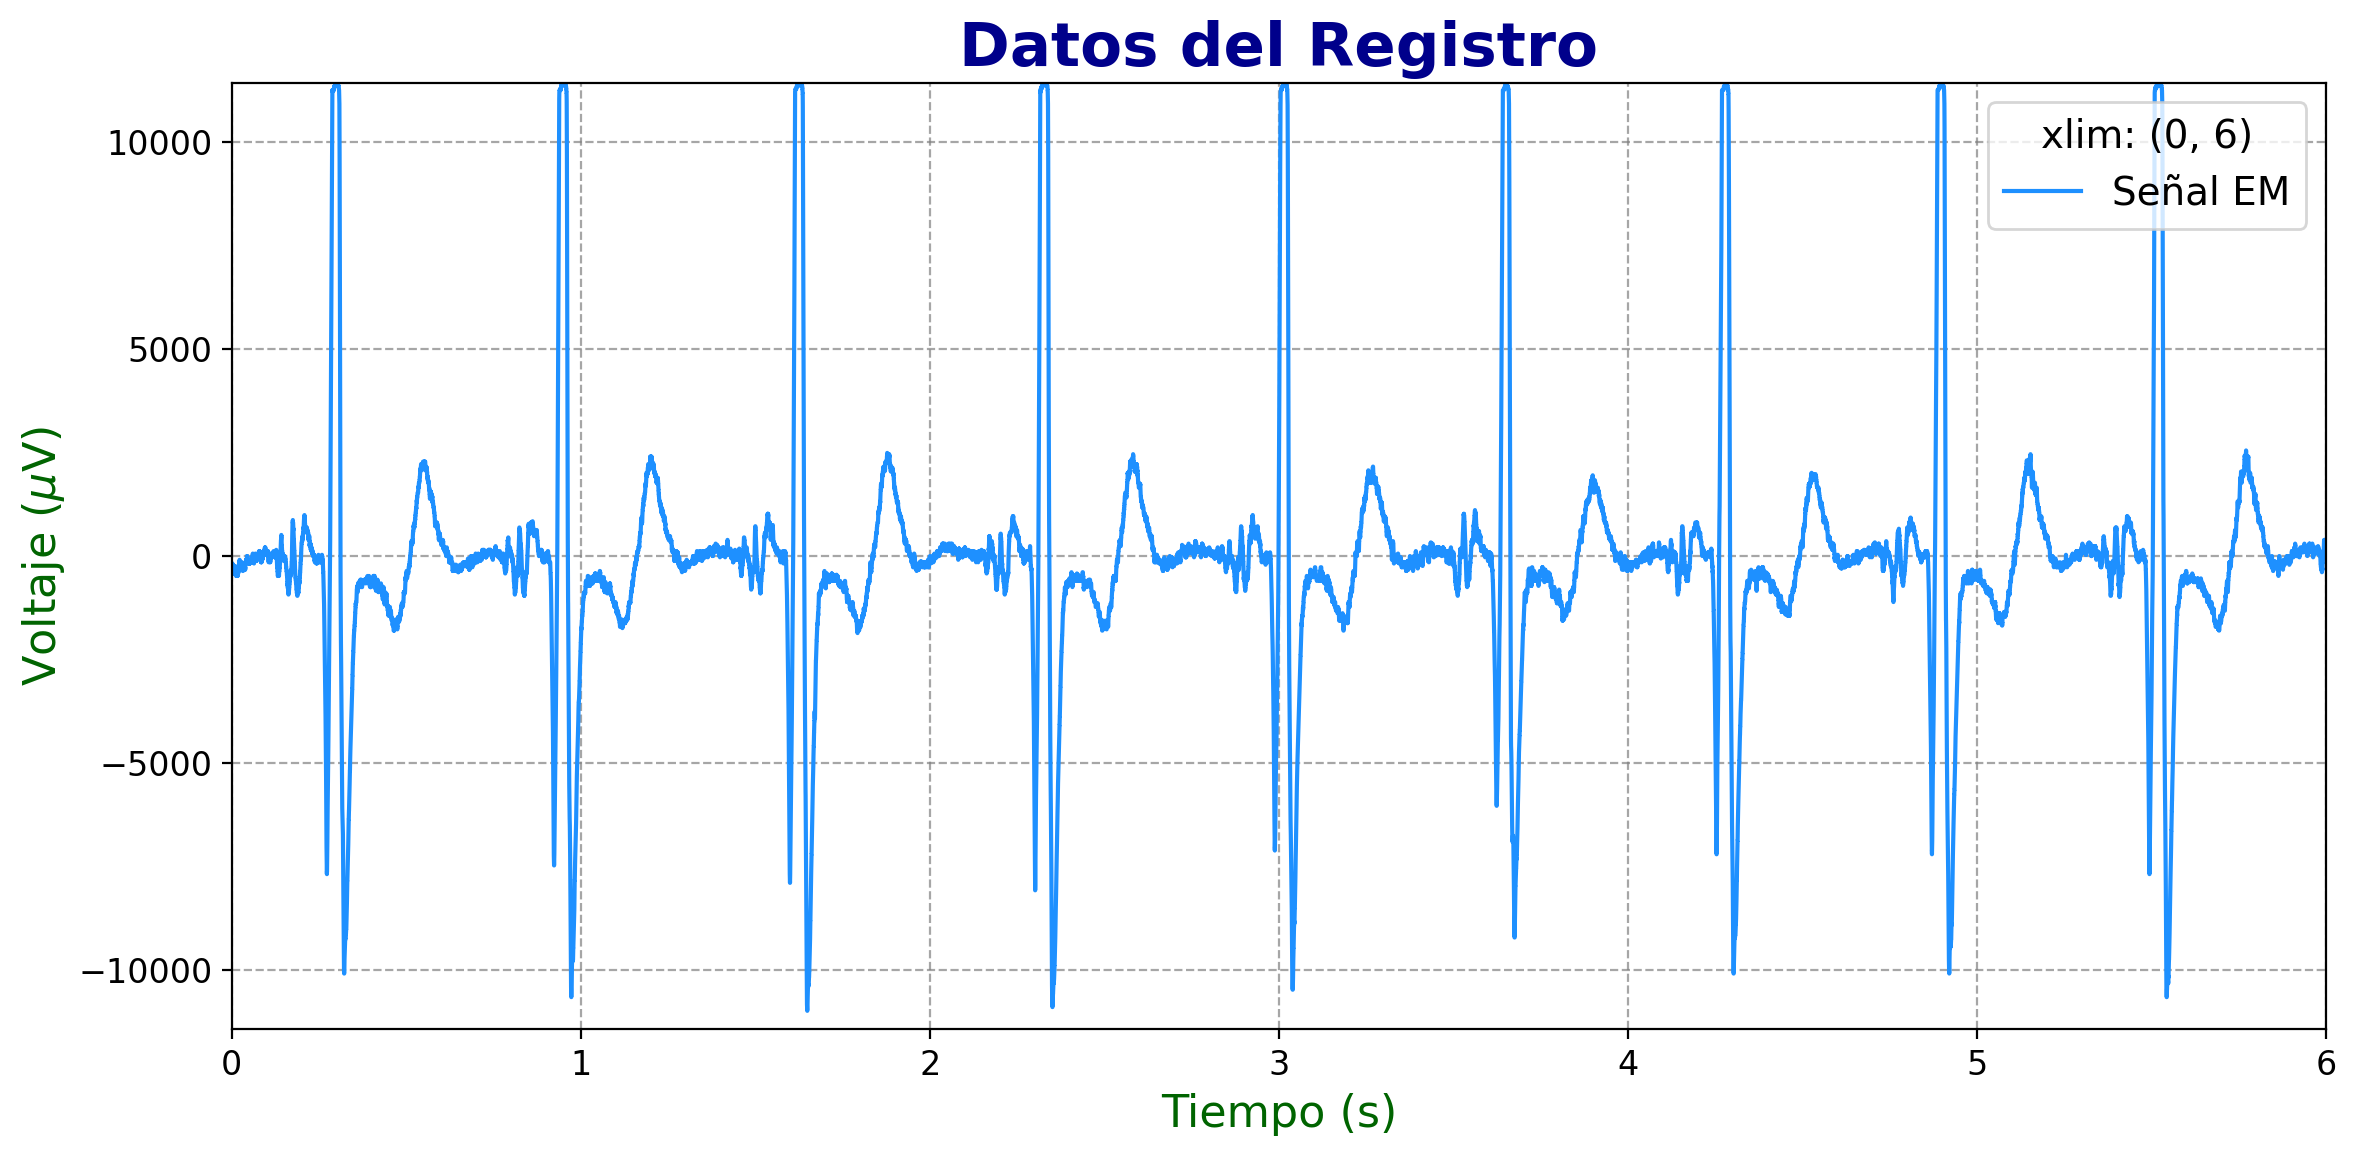

In [4]:
ECG.visualizar(0,6)

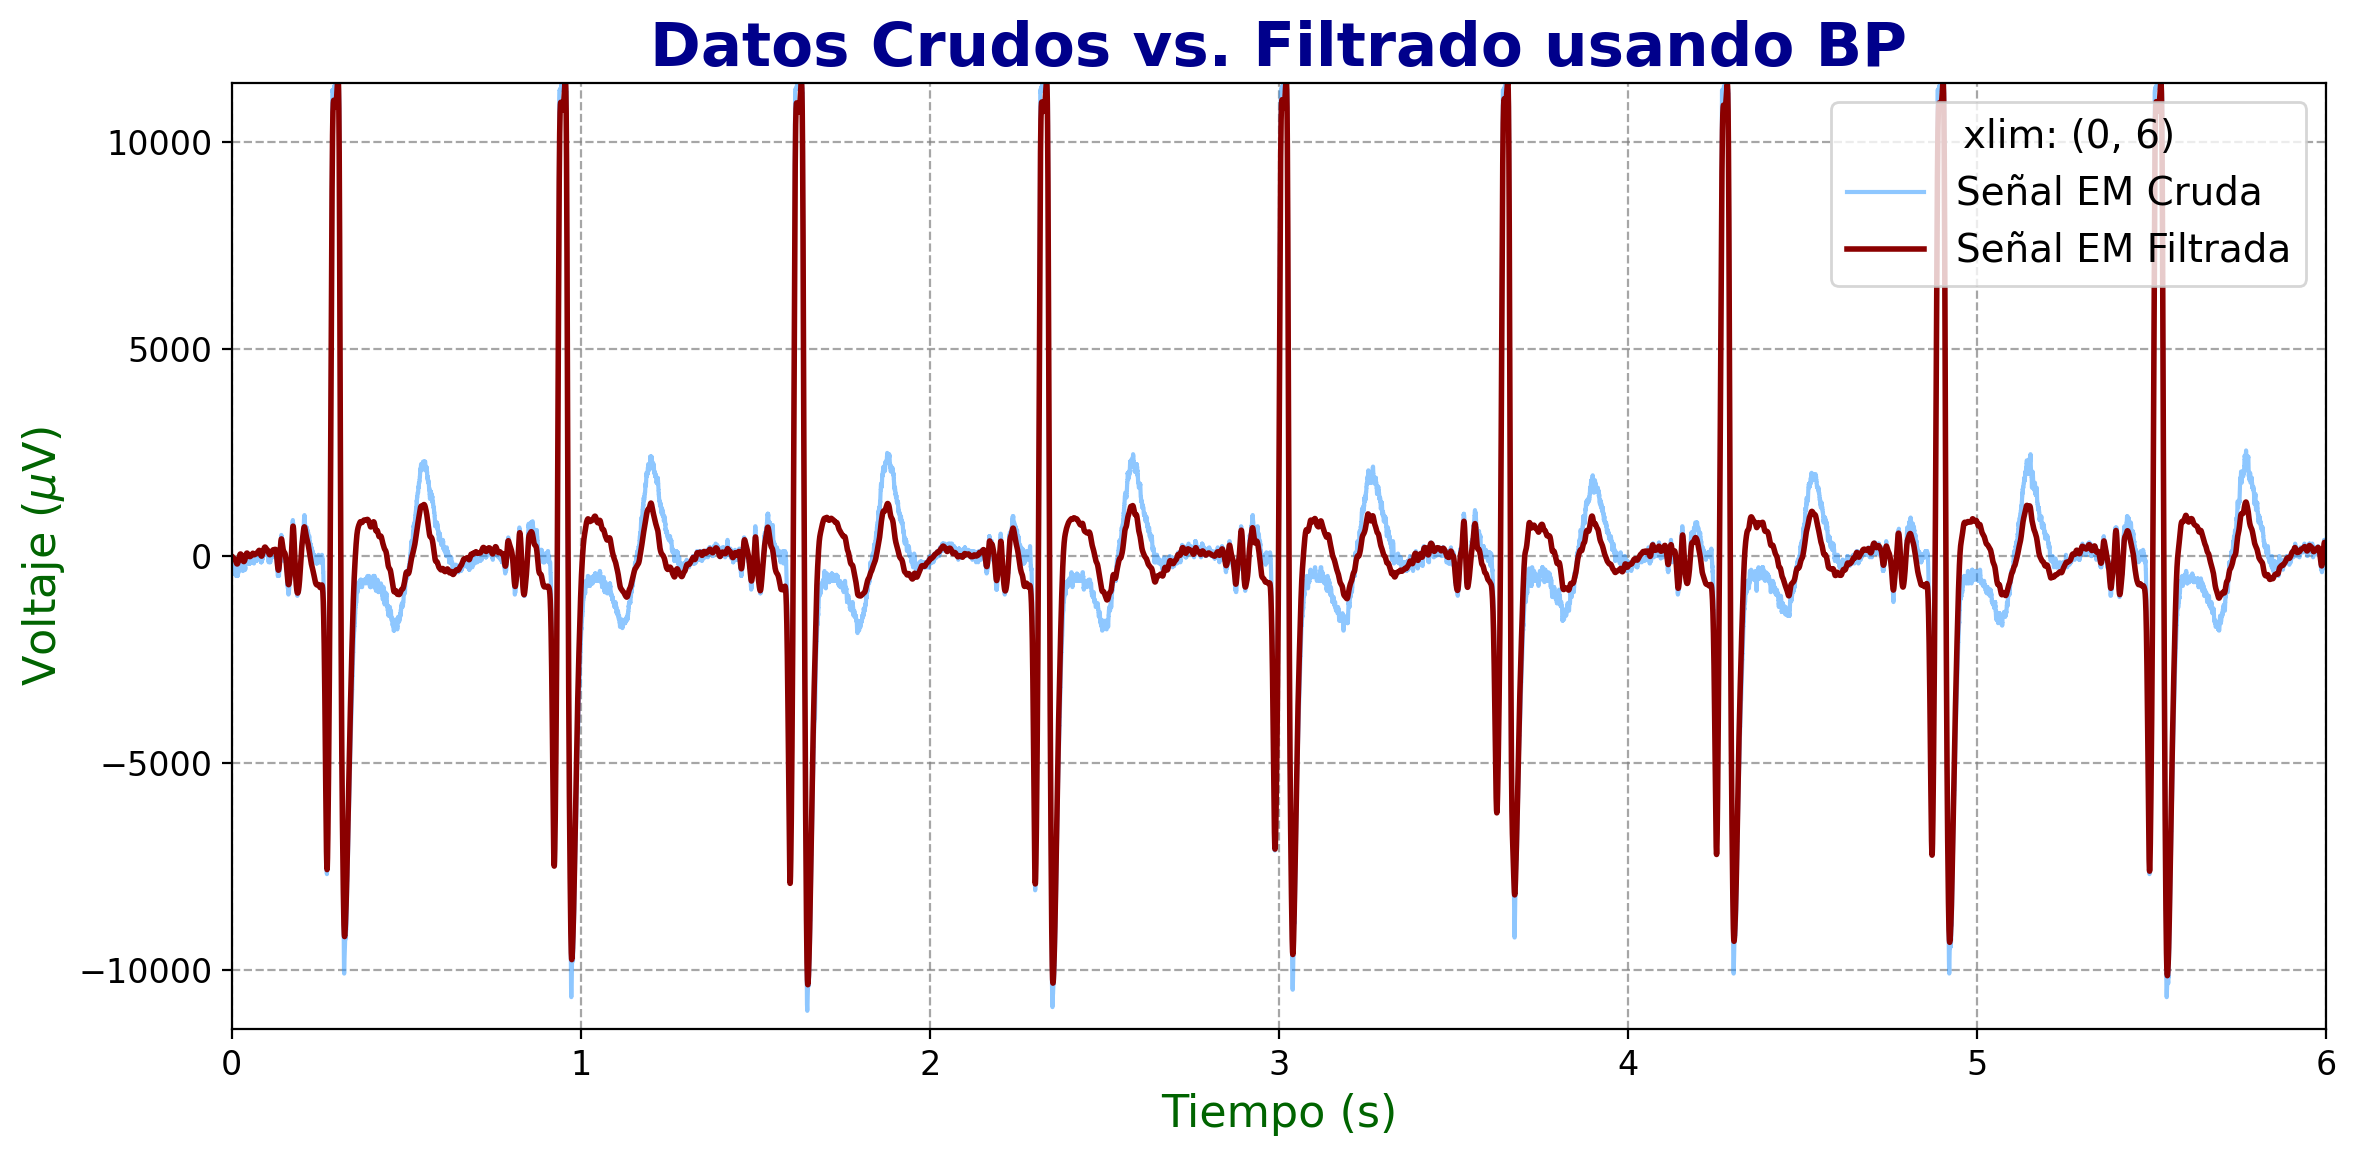

In [5]:
ECG.visualizar_filtrada(0,6,5,90)

In [6]:
ECG_F=EM(señal=ECG.Señal_filtrada_Bandpass(5,90), tasa_muestra=ECG.tasa_muestra ,tipo="EKG") #Creamos un nuevo objeto ECG filtrado

 Cortamos el segmento del registro con el que vamos a trabajar

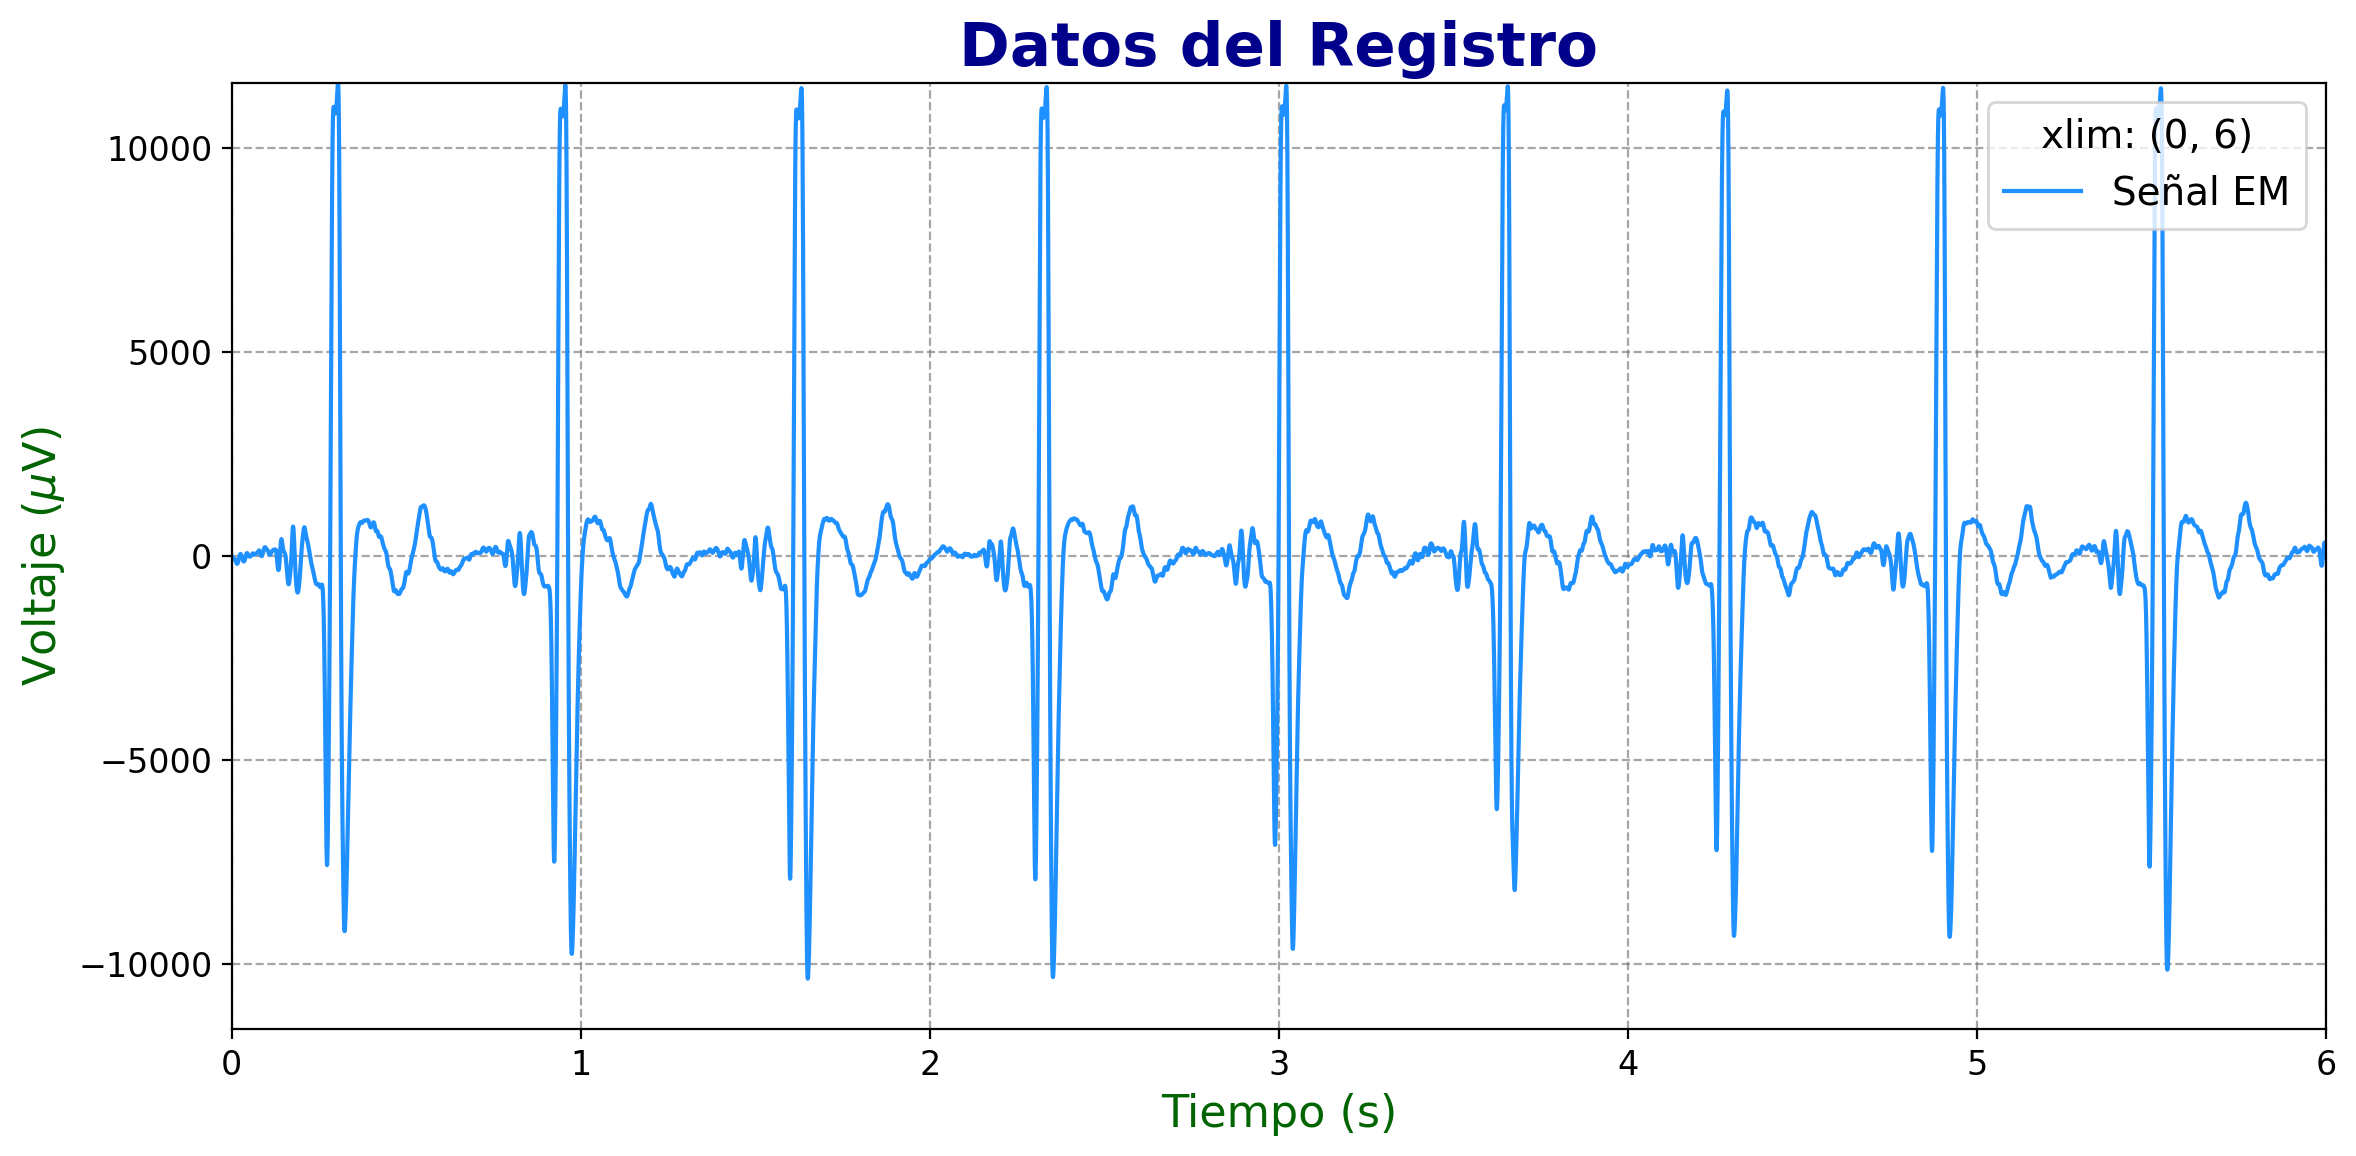

In [7]:
# Cortamos el segmento que vamos a analizar
ECG_FR = ECG_F.cortar_segmento(0,6)
ECG_FR.visualizar(0, 6)  # Graficamos el segmento del nuevo EKG

In [8]:
#Definimos el segmento del registro como EKG
ECG_FR.set_tipo('EKG') 

## Métodos Basicos para EKG

Para los siguientes métodos que vamos a ocupar es preferible ocupar un segmento del registro. 

Los métodos que vamos a menciona ya se mostraron en el Tutorial "Human electrocardiogram basic analysis", asi que vamos a mostrar como llamar a los metodos:

* Detección de Picos R y intervalos R-R:  EKG.PicosR(T) tiene como parametro T el umbral y regresa los indices donde ocurren los Picos R

Recuerda usar un segmento del registro


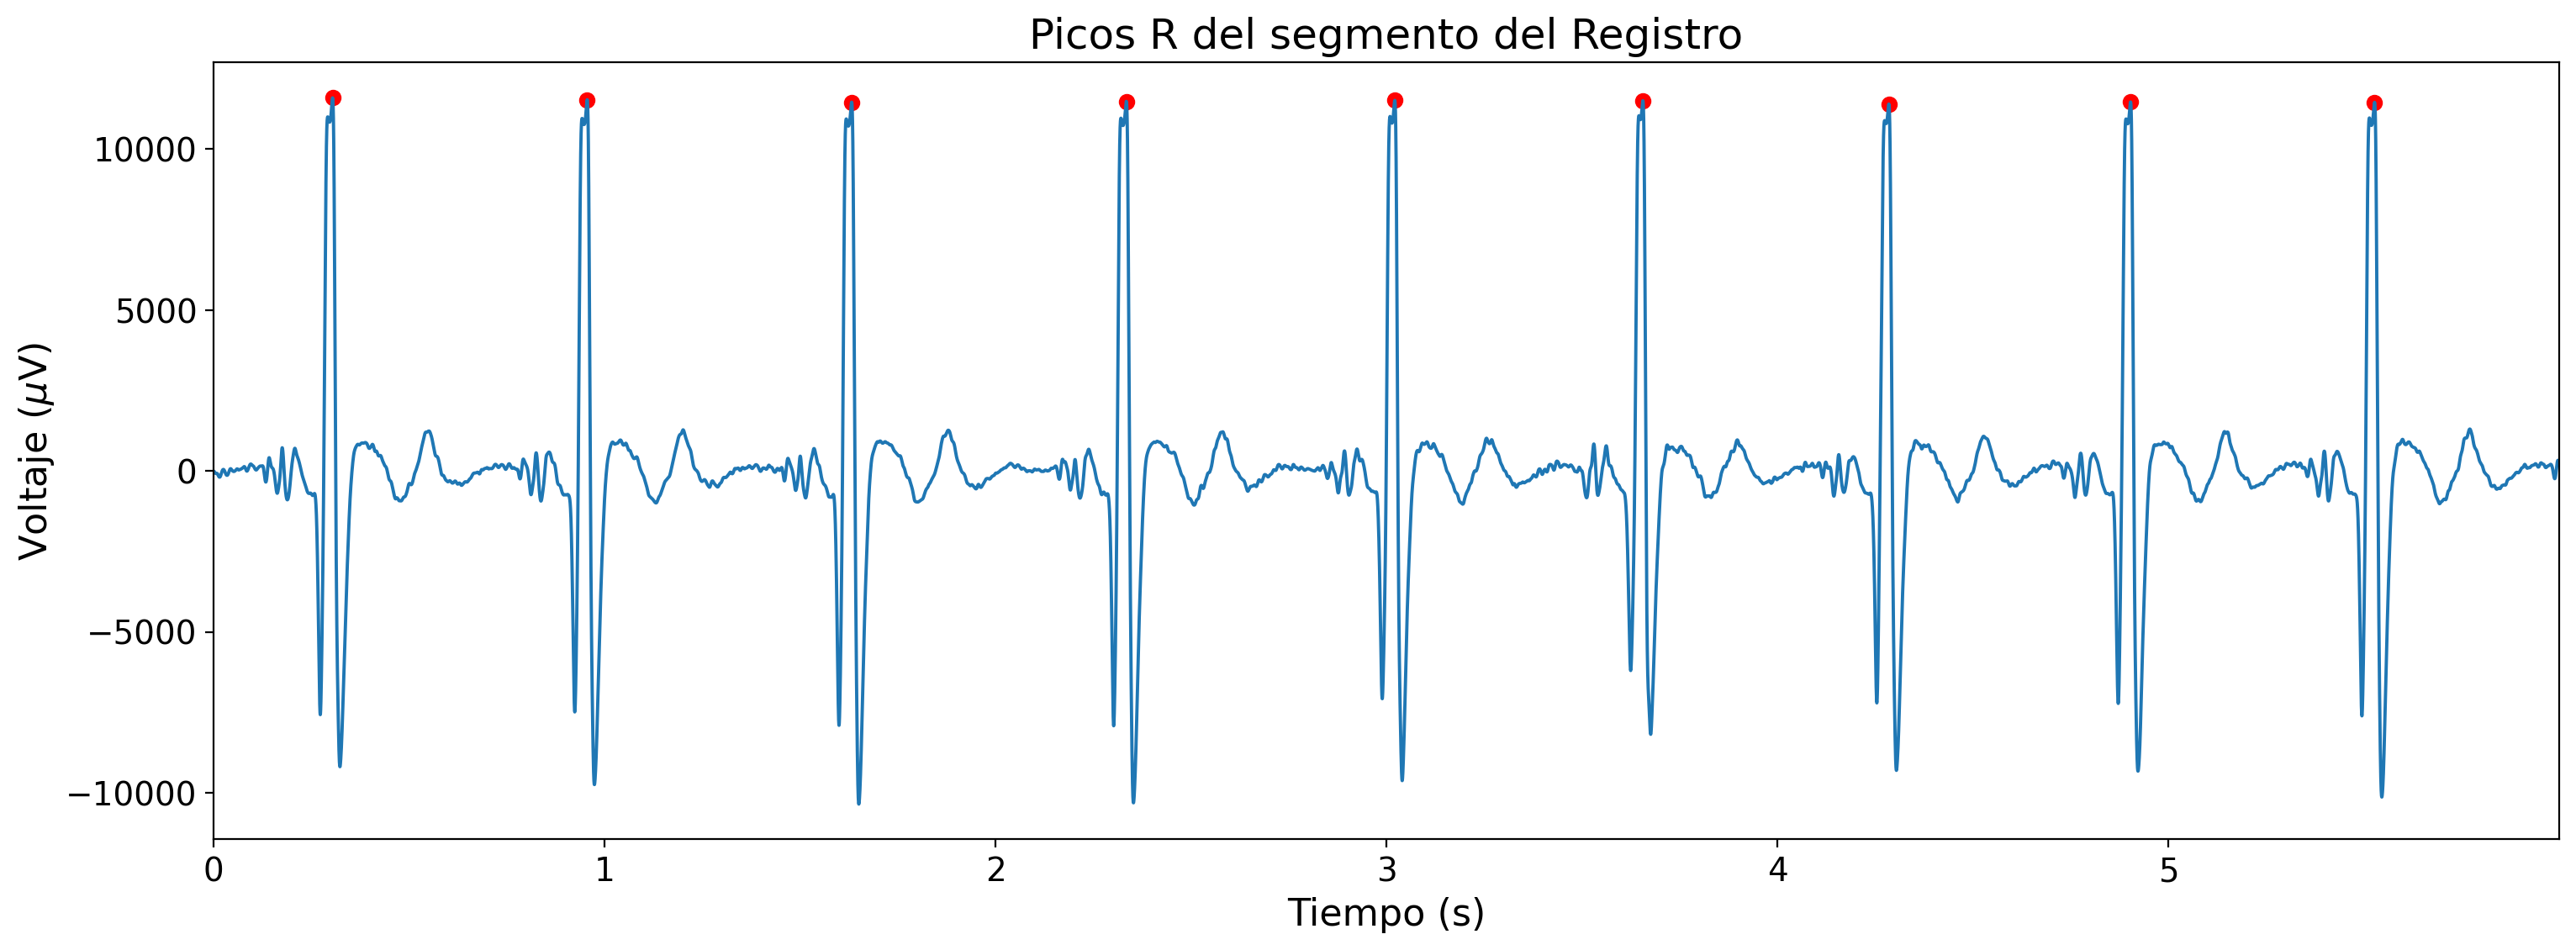

In [9]:
A=ECG_FR.PicosR(0.87) 

* Latidos por Minuto y Frecuencia Cardiaca: EKG.LPM_FC(mxs_indices) tiene como parametro los indices donde ocurren los Picos R y regresa una lista con el promedio de latidos por minuto, frecuencia cardiaca.

Latidos por minuto: 90.00145576141614


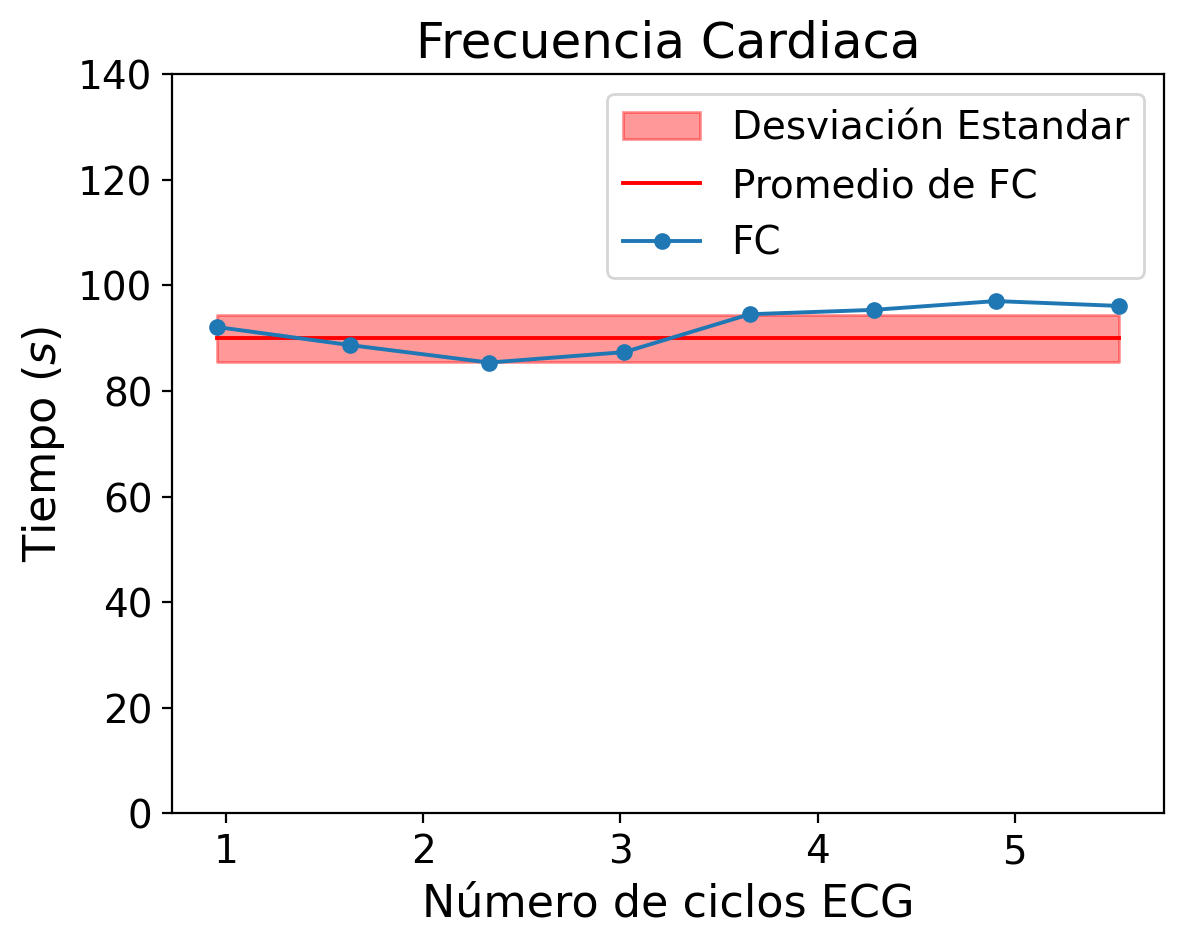

In [10]:
B=ECG_FR.LPM_FC(mxs_indices=A)

* Intervalos R-R: Tenemos los métodos EKG.Intervalos_RR(mxs_indices) que tiene como parametros los indices donde ocurren los picos R  y regresa una lista con los intervalos R-R y su promedio

Promedio del intervalo R-R :  0.6529128211086668


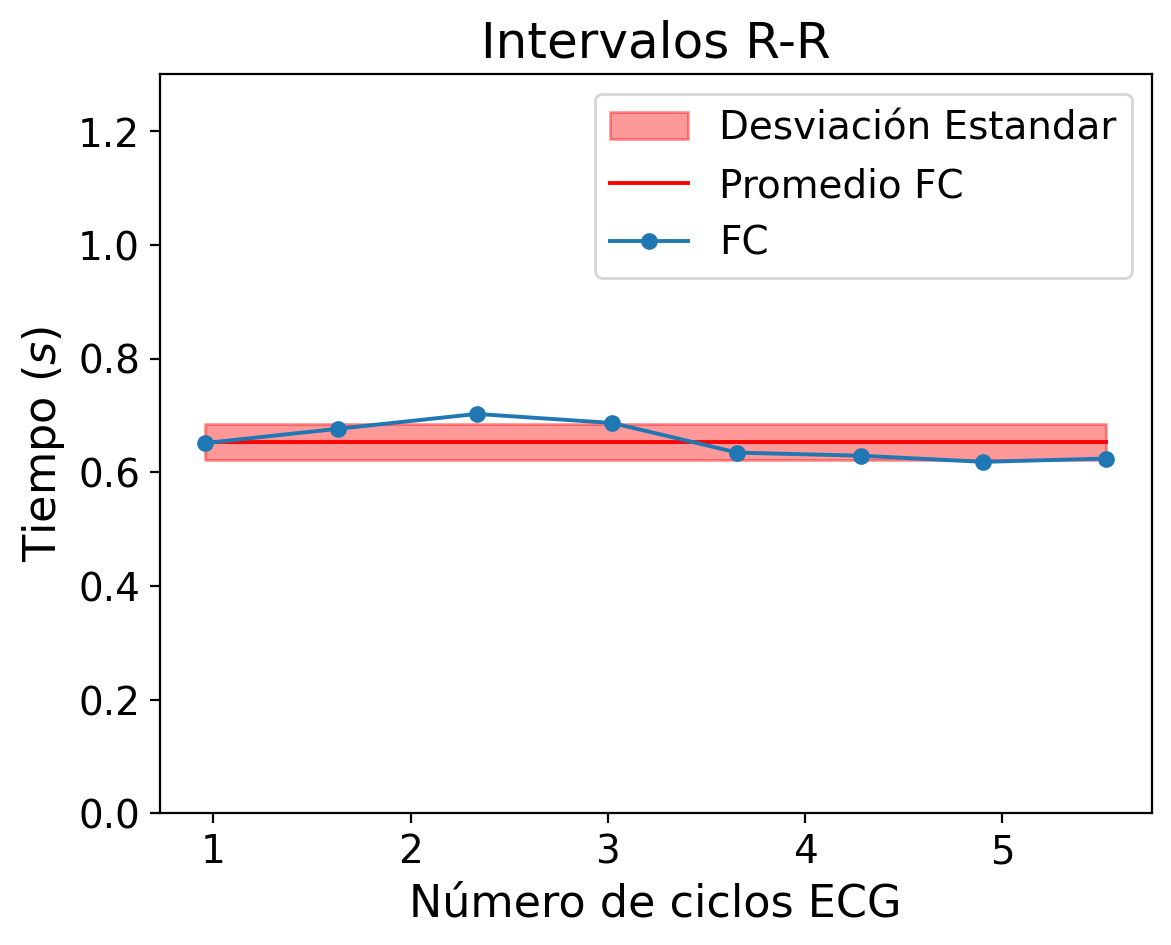

In [11]:
C=ECG_FR.Intervalos_RR(mxs_indices=A) 

* El siguiente método muestra la relación entre Frecuencia Cardiaca e Intervalos R-R

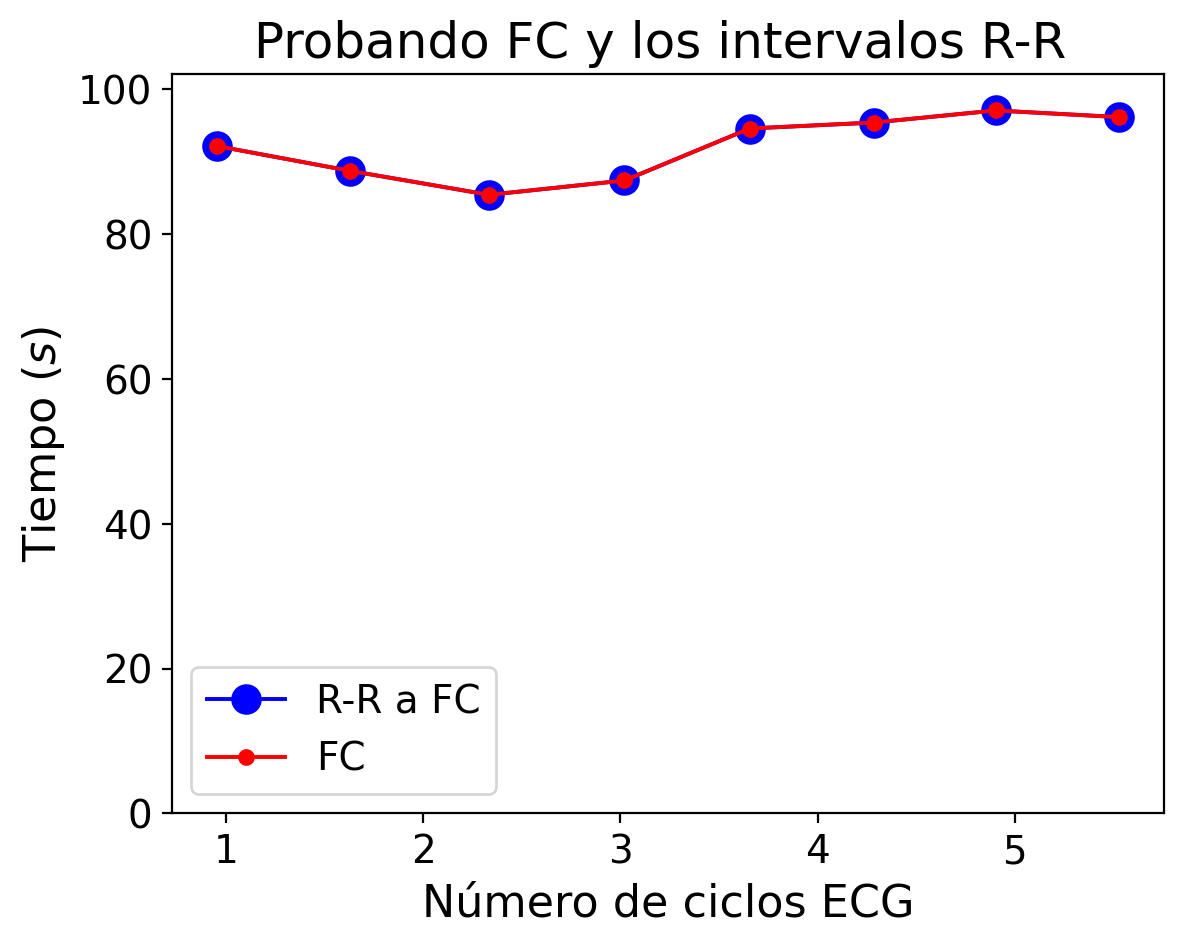

In [12]:
ECG_FR.Prueba_FCRR(xx=C[0],heart_rate=B[-1],mxs_indices=A) 

* Componentes del ECG: EKG.QRS1(mxs_indices) tiene como parametro los indices donde ocurren los picos R y regresa los  indices los puntos mínimos antes y despues del pico R.


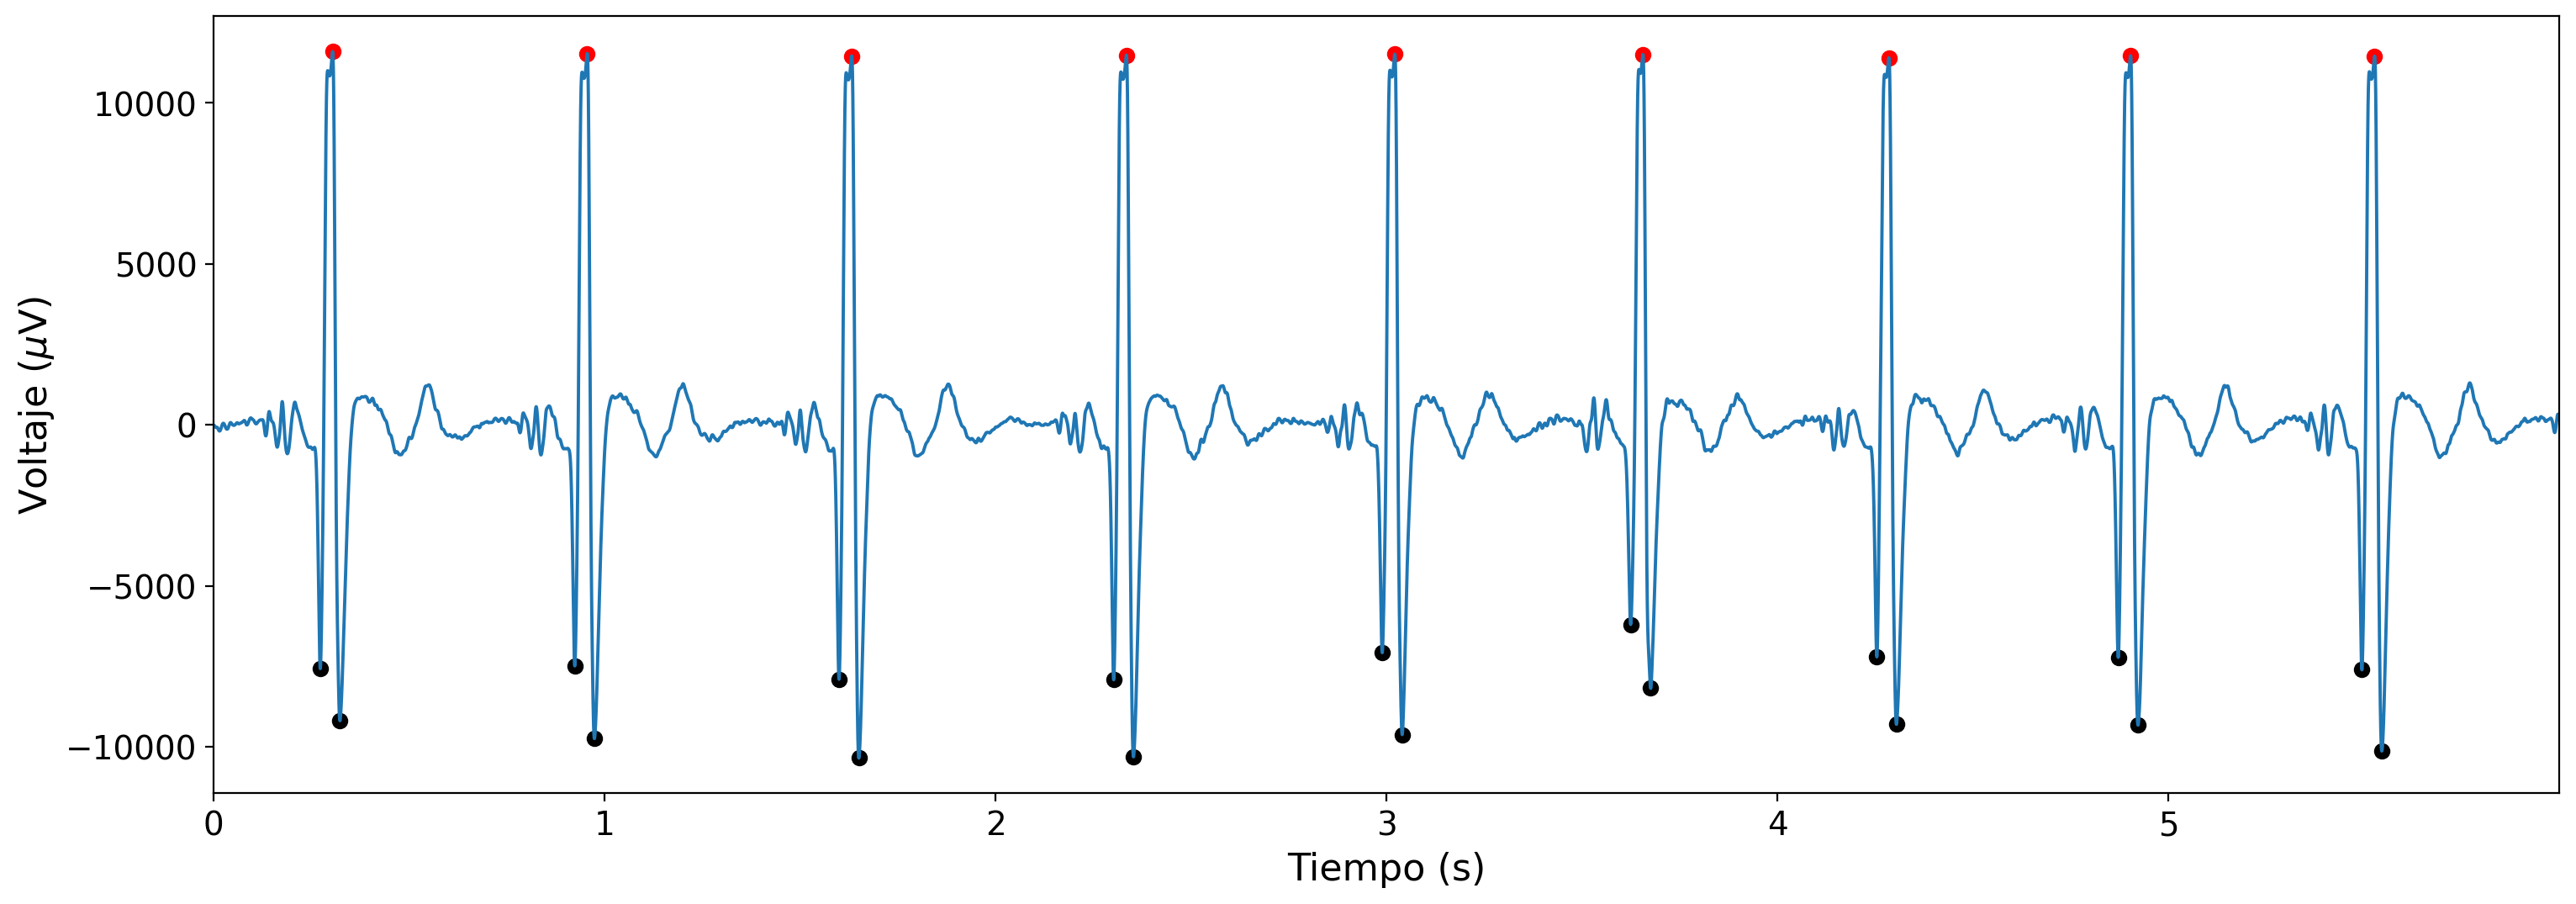

In [13]:
 D=ECG_FR.QRS(mxs_indices=A) #Regresa los puntos azules

El promedio en segundos del complejo QRS es:  0.05060002488556817


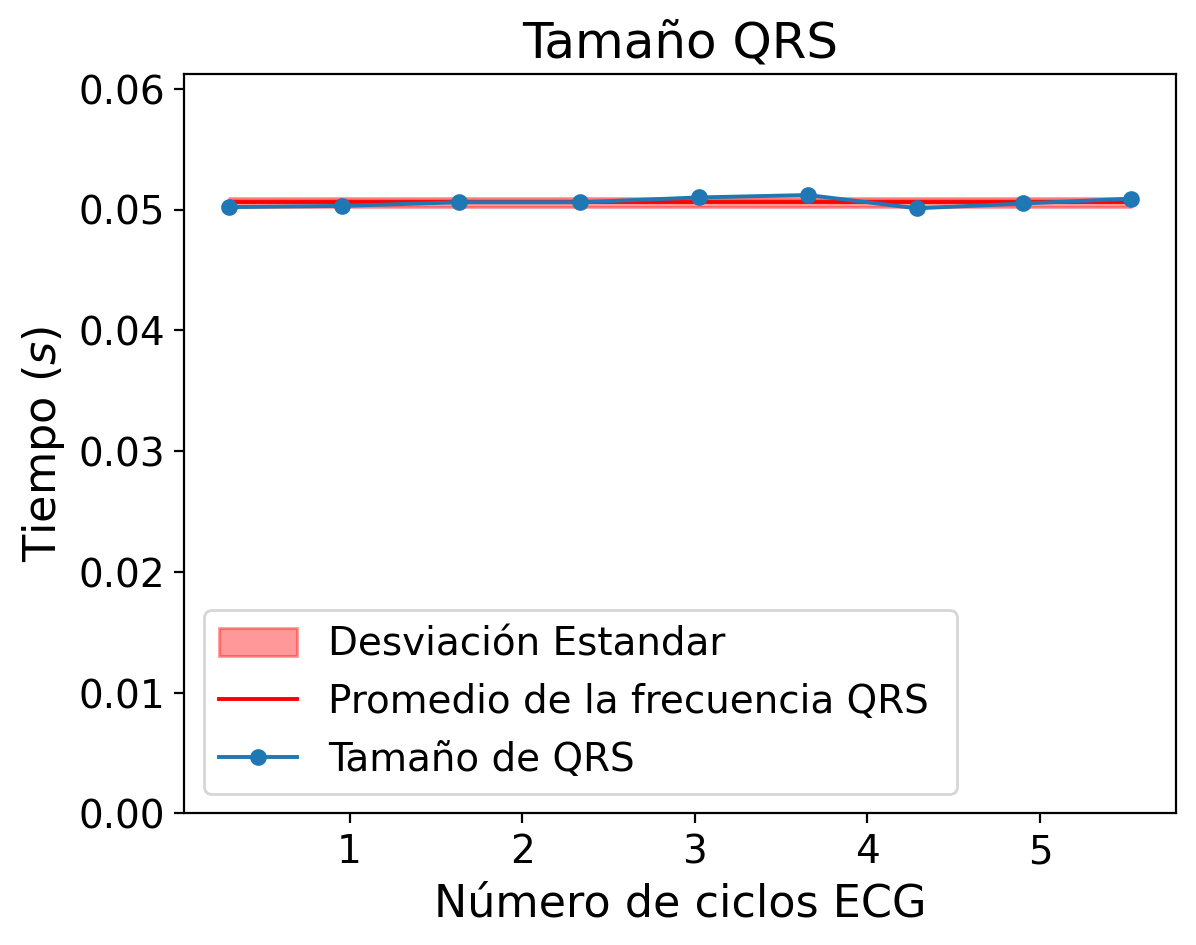

In [14]:
E=ECG_FR.Tamaño_QRS(mxs_indices=A,mins_try=D)

* La onda P debido a su baja amplitud y corta duración es más complicado estimarla, por esto se creo el siguiente método que  estima el inicio y fin de esta: ECG.P_wave(mxs_indices,mins_try,nn,VD) donde aquí son importante los parametros nn y VD que son el número de muestras antes del mínimo (Q) donde se buscará el inicio de la onda P y ventana de muestras para calcular la derivada (cuán brusco cambia el voltaje) respectivamente.

In [15]:
E=ECG_FR.P_wave(mxs_indices=A,mins_try=D,nn=800,VD=200) 

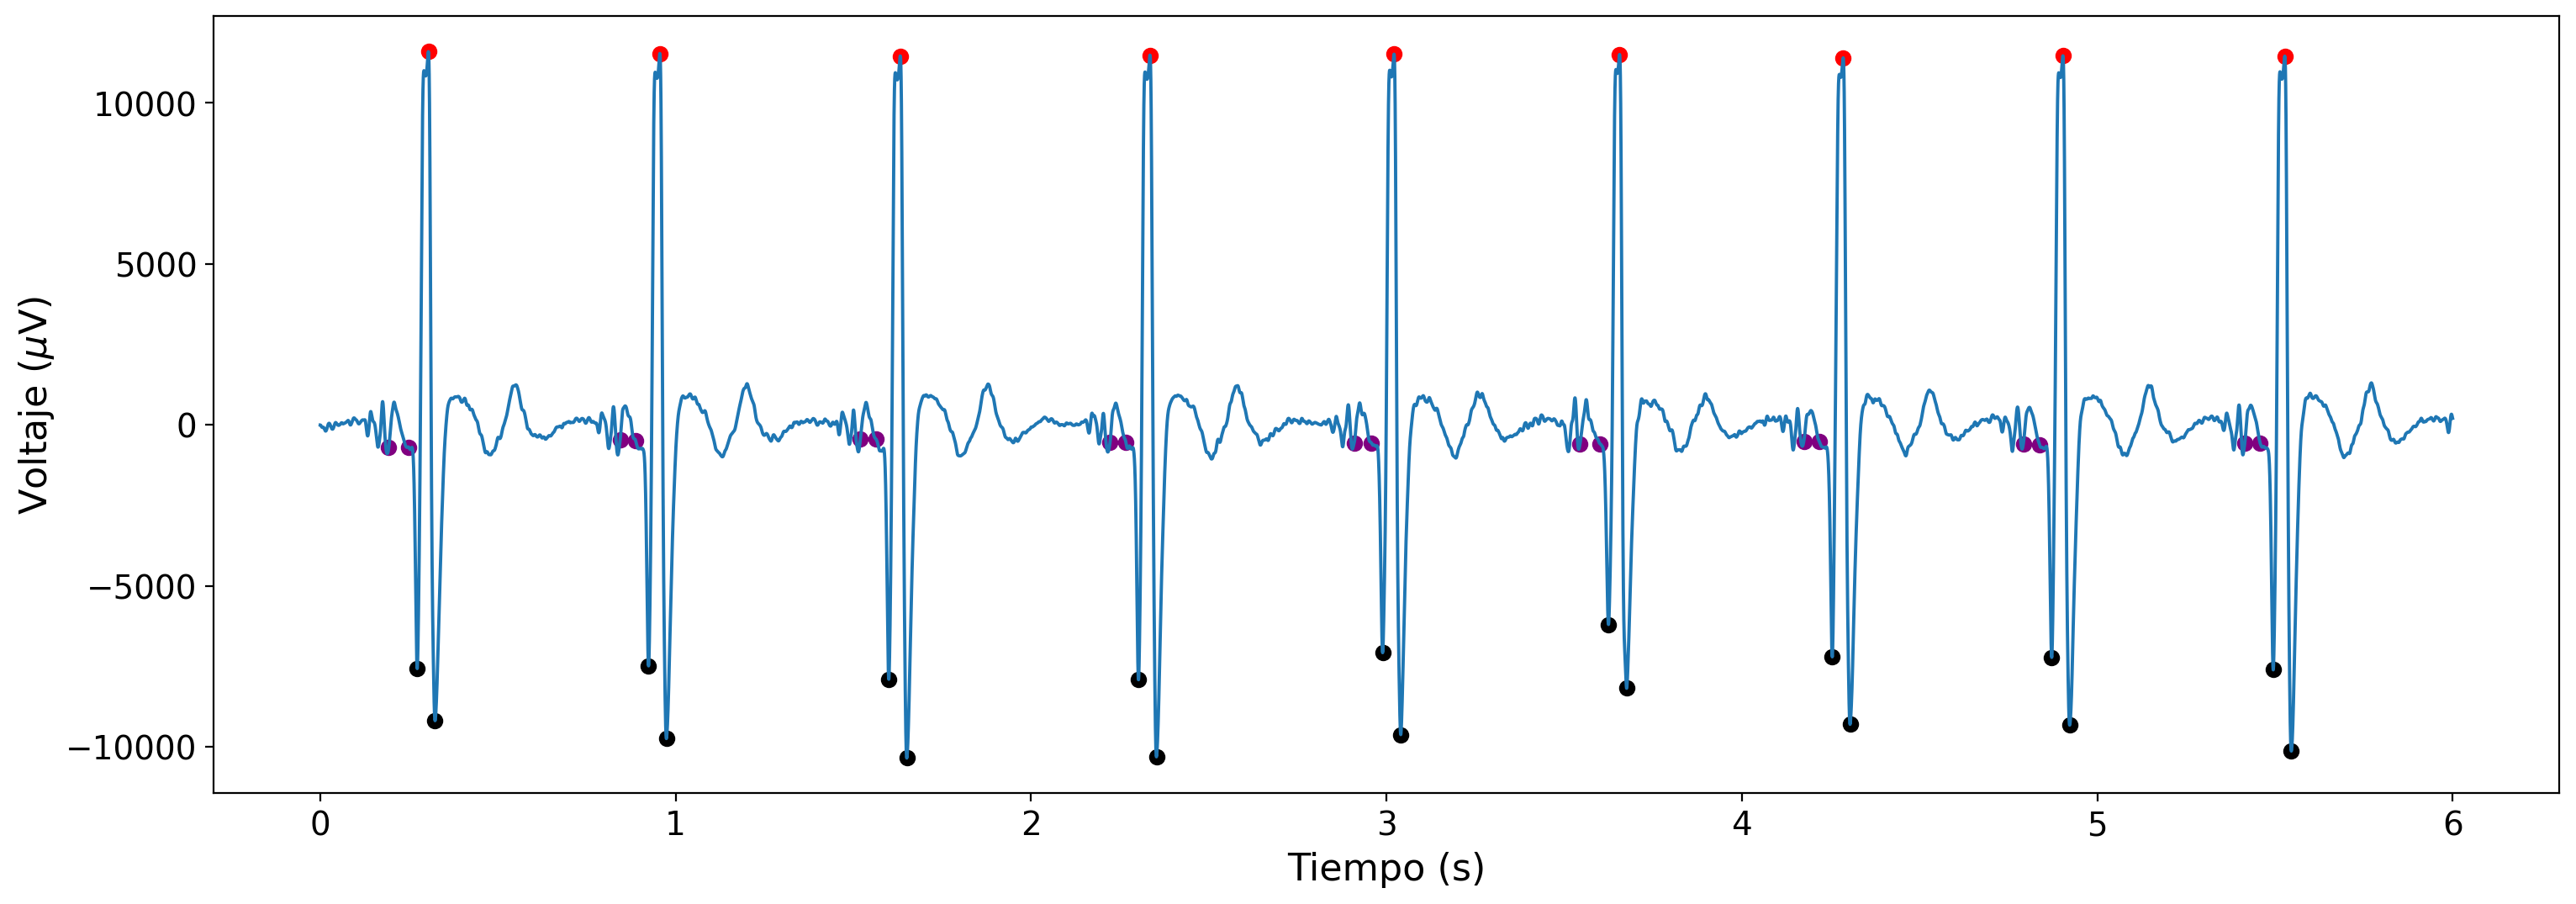

In [16]:
plt.figure(figsize=(18,6))
plt.xlabel(r'Tiempo (s)')
plt.ylabel(r'Voltaje ($\mu$V)')
plt.plot(ECG_FR.vector_tiempo,ECG_FR.señal)
plt.scatter(ECG_FR.vector_tiempo[A], ECG_FR.señal[A], color='r')
plt.scatter(ECG_FR.vector_tiempo[D], ECG_FR.señal[D], color='k')
plt.scatter(ECG_FR.vector_tiempo[E], ECG_FR.señal[E], color='purple')
plt.show()

Para hacer un Zoom a la gráfica se puede ocupar el siguiente código

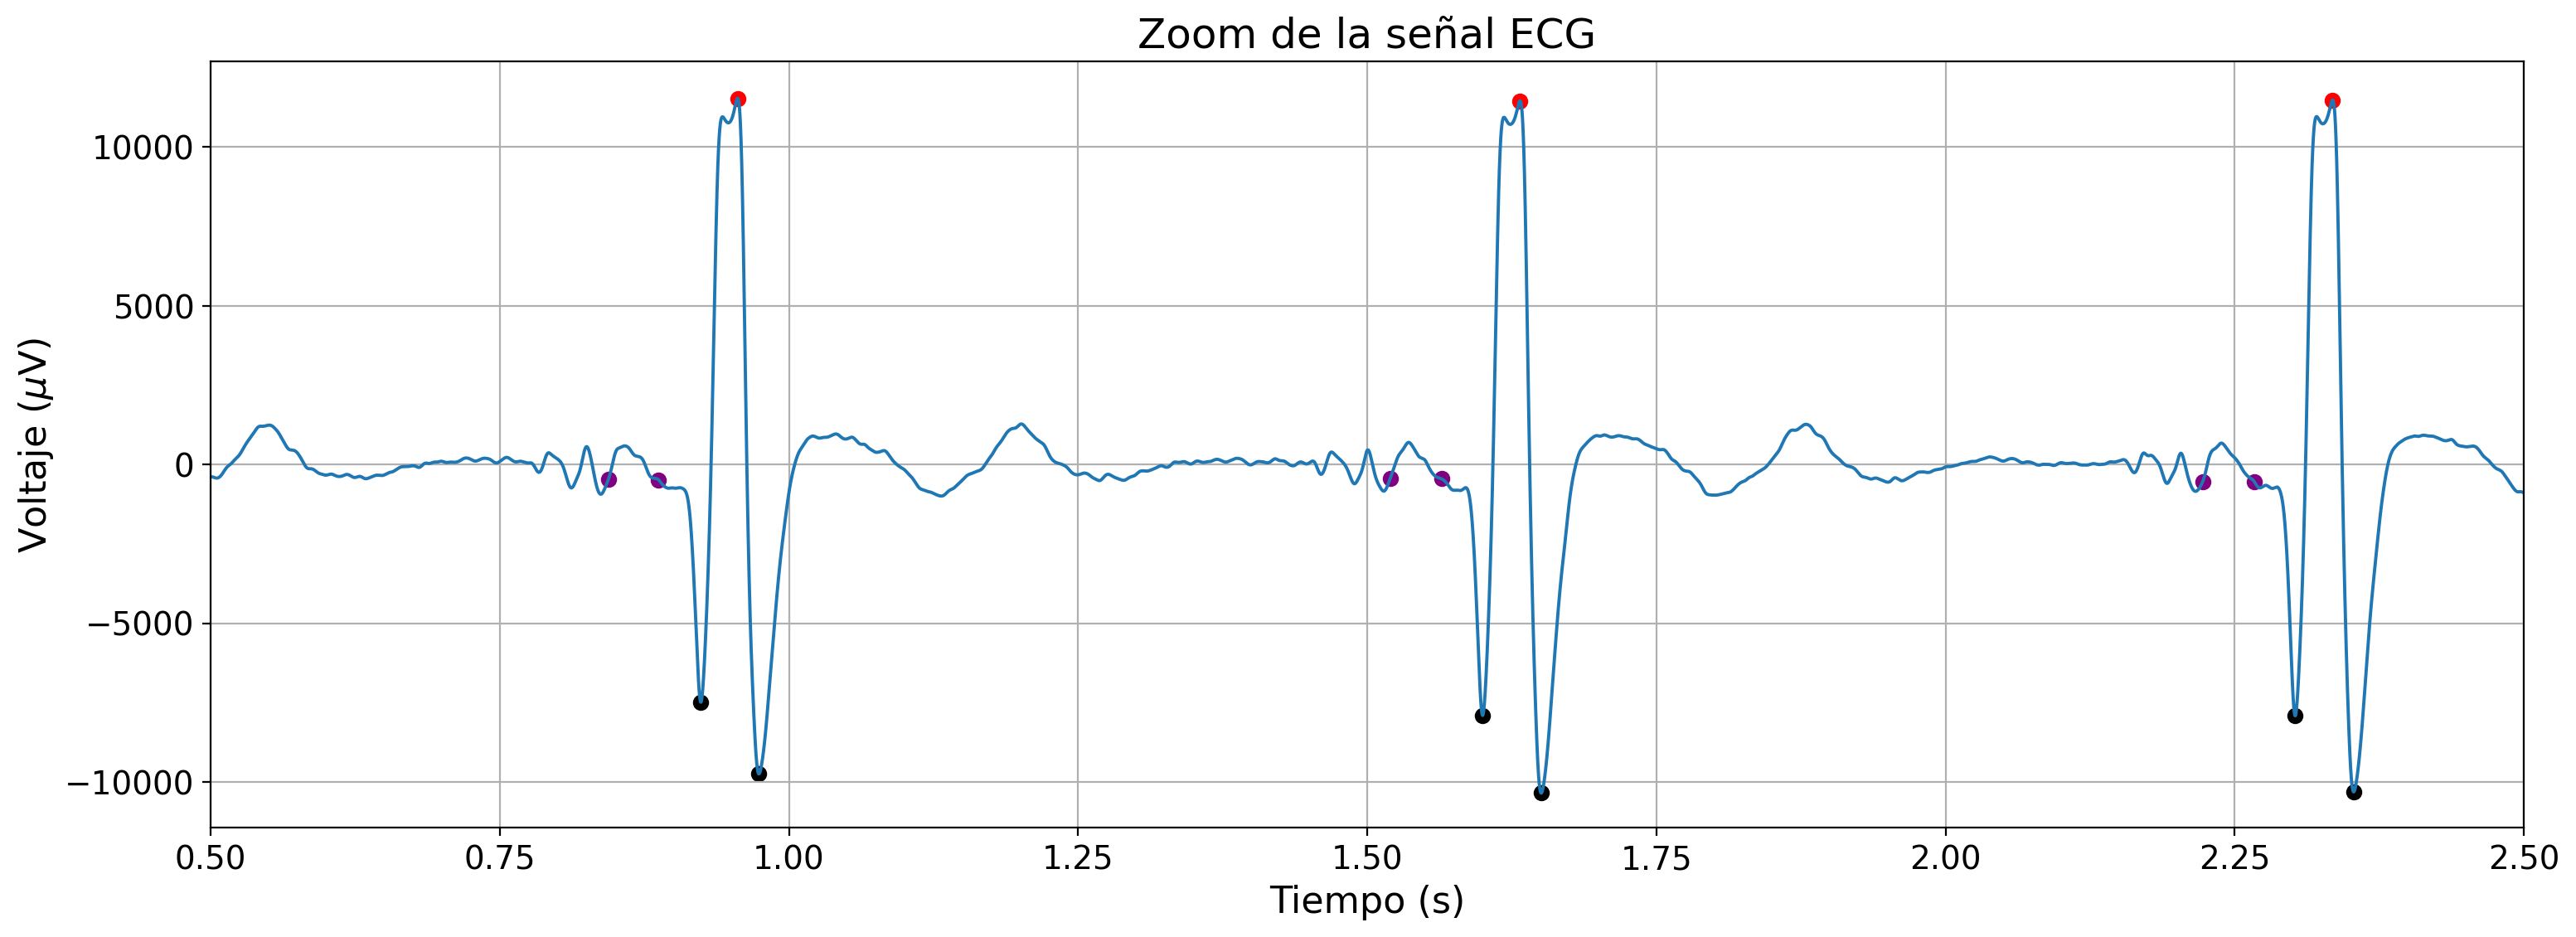

In [17]:
plt.figure(figsize=(18,6))
plt.xlabel(r'Tiempo (s)')
plt.ylabel(r'Voltaje ($\mu$V)')
plt.plot(ECG_FR.vector_tiempo, ECG_FR.señal)
plt.scatter(ECG_FR.vector_tiempo[A], ECG_FR.señal[A], color='r')
plt.scatter(ECG_FR.vector_tiempo[D], ECG_FR.señal[D], color='k')
plt.scatter(ECG_FR.vector_tiempo[E], ECG_FR.señal[E], color='purple')

# Zoom:
plt.xlim(0.5, 2.5)  # Zoom en eje X (tiempo)

plt.title("Zoom de la señal ECG")
plt.grid(True)
plt.show()

Promedio en segundos de la P-wave:  0.04615002269701535


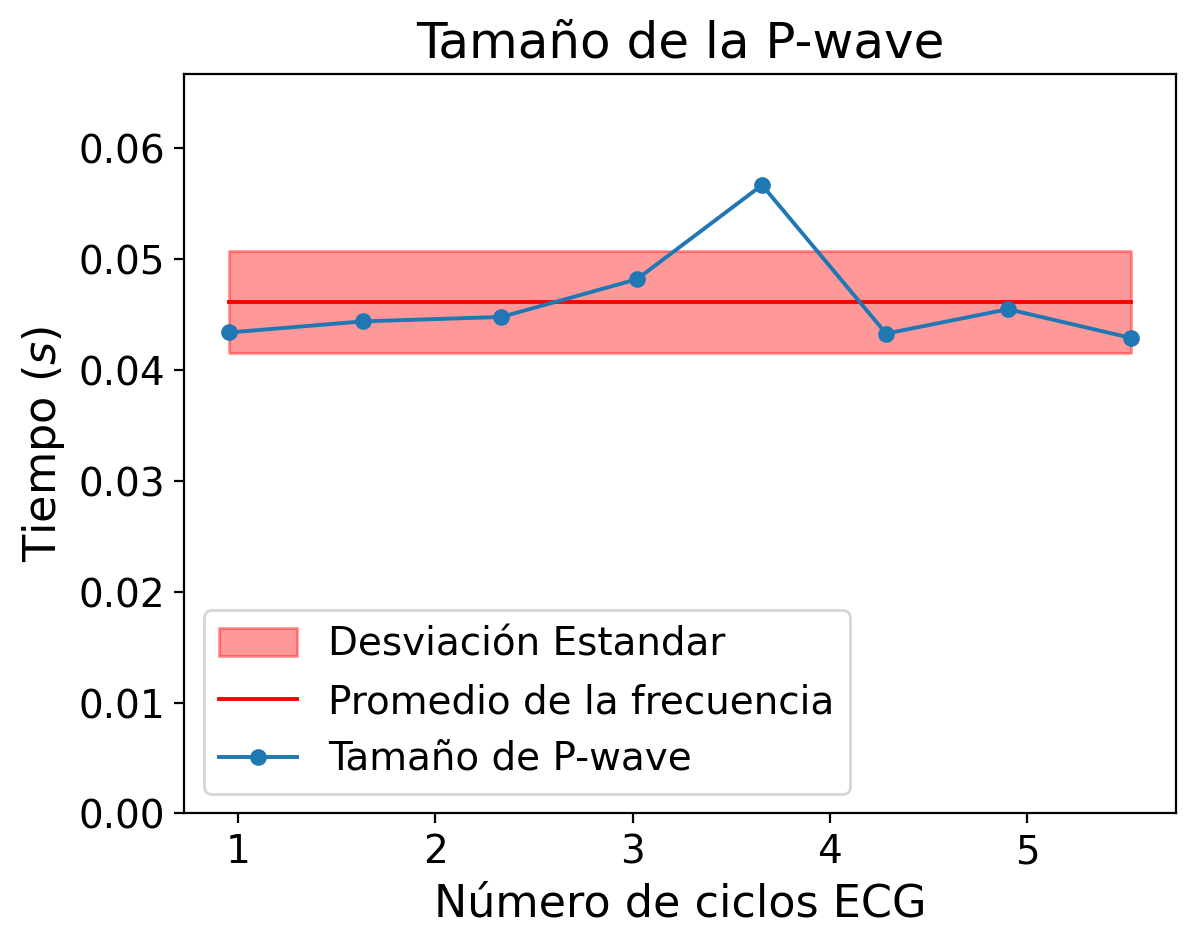

In [18]:
ECG_FR.Tamaño_Pwave(E[0],E[1],A)

* Para la detección de la onda T se implementará un método similar al utilizado para la onda P, en el sentido de que se requerirán parámetros como el número de muestras posteriores al pico R para iniciar la búsqueda del comienzo y final de la onda. Asimismo, se emplearán ventanas de muestras para el cálculo de la derivada: una ventana inicial más amplia, destinada a identificar un inicio suave de la onda T, y una ventana final más estrecha, enfocada en detectar un punto de inflexión agudo al final de la misma.

In [19]:
F=ECG_FR.T_wave(mxs_indices=A,mins_try=D,nni=1500,nnf=3000,VDI=200,VDF=100)

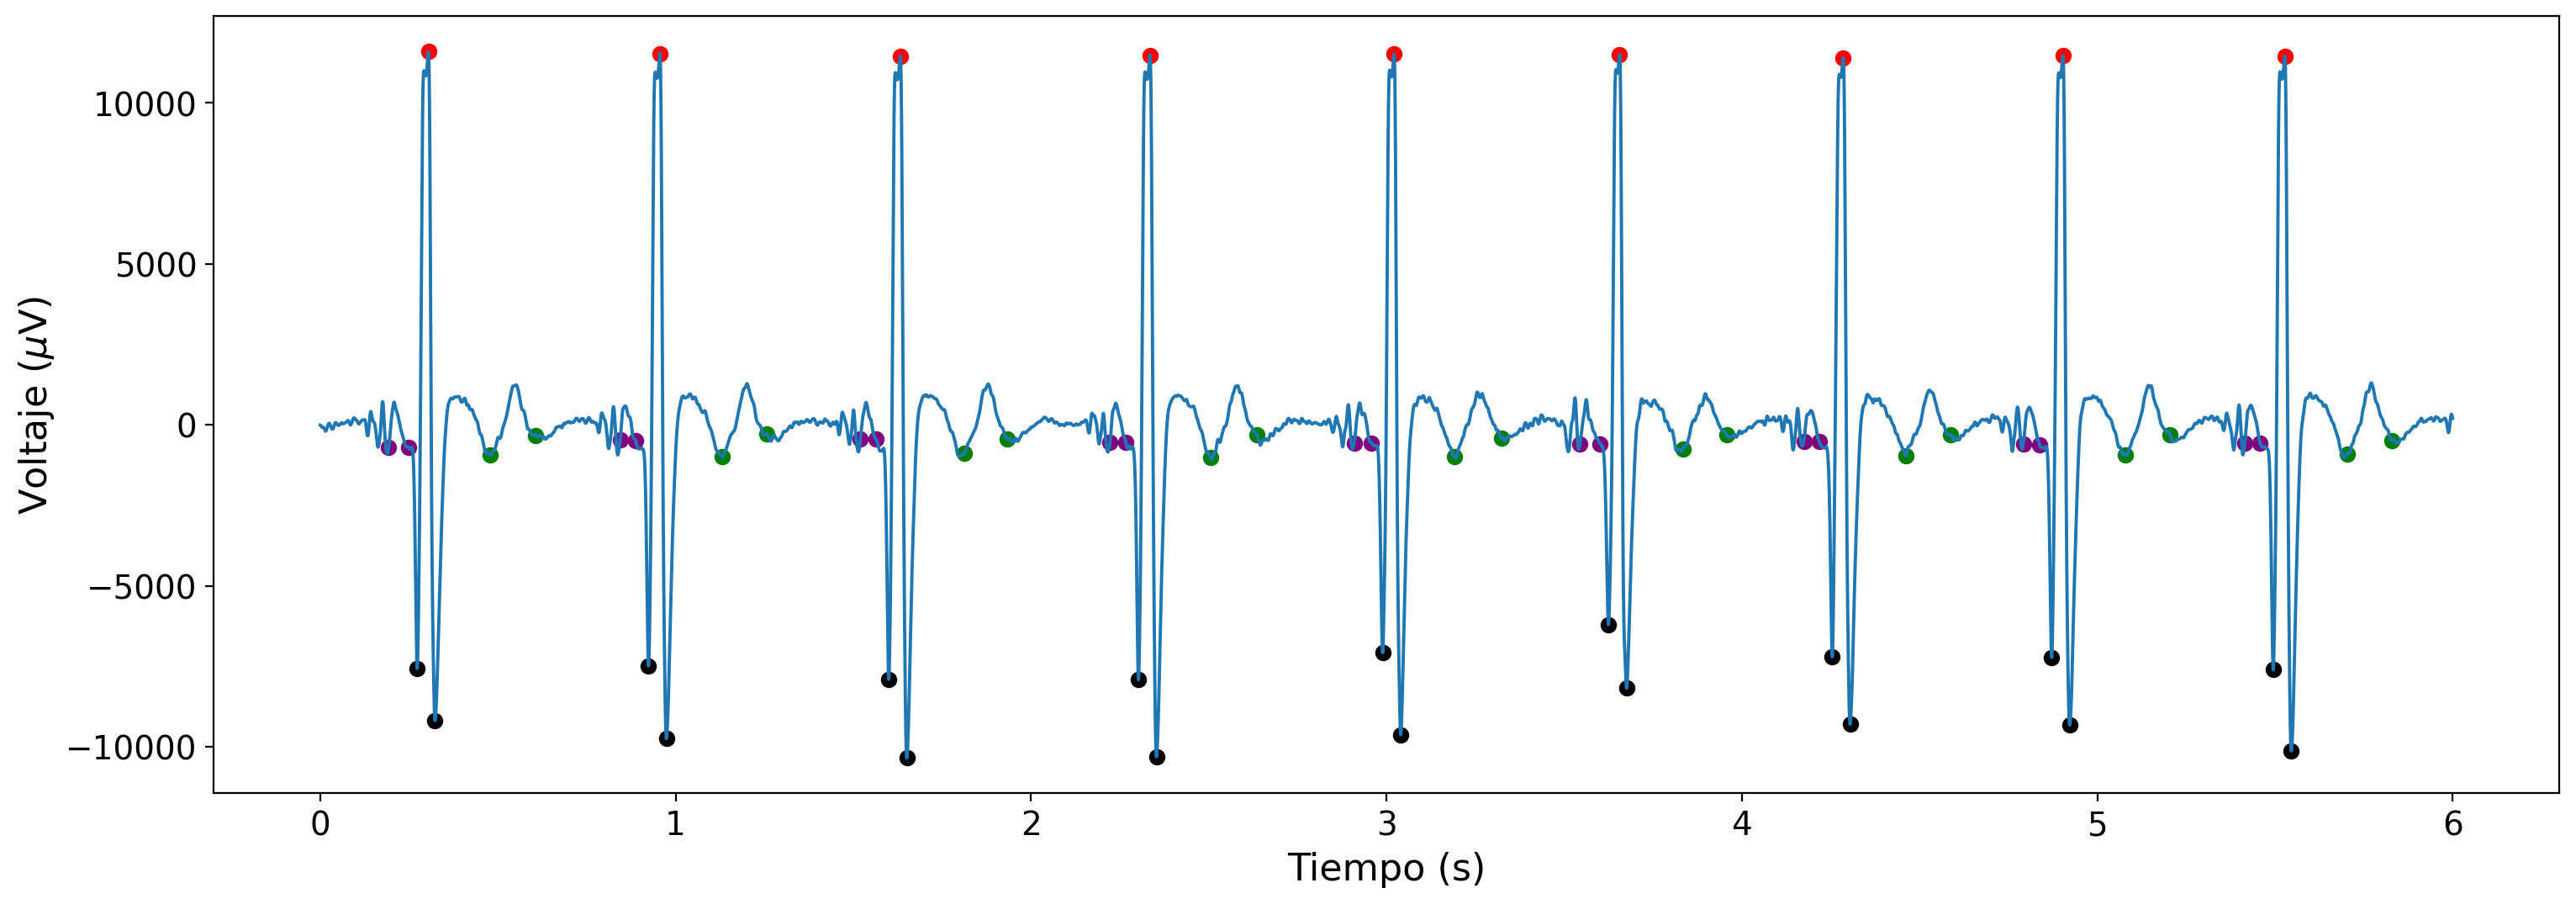

In [20]:
plt.figure(figsize=(18,6))
plt.xlabel(r'Tiempo (s)')
plt.ylabel(r'Voltaje ($\mu$V)')
plt.plot(ECG_FR.vector_tiempo,ECG_FR.señal)
plt.scatter(ECG_FR.vector_tiempo[A], ECG_FR.señal[A], color='r')
plt.scatter(ECG_FR.vector_tiempo[D], ECG_FR.señal[D], color='k')
plt.scatter(ECG_FR.vector_tiempo[E], ECG_FR.señal[E], color='purple')
plt.scatter(ECG_FR.vector_tiempo[F], ECG_FR.señal[F], color='green')
plt.show()

Promedio en segundos de la T-wave:  0.126750062336873


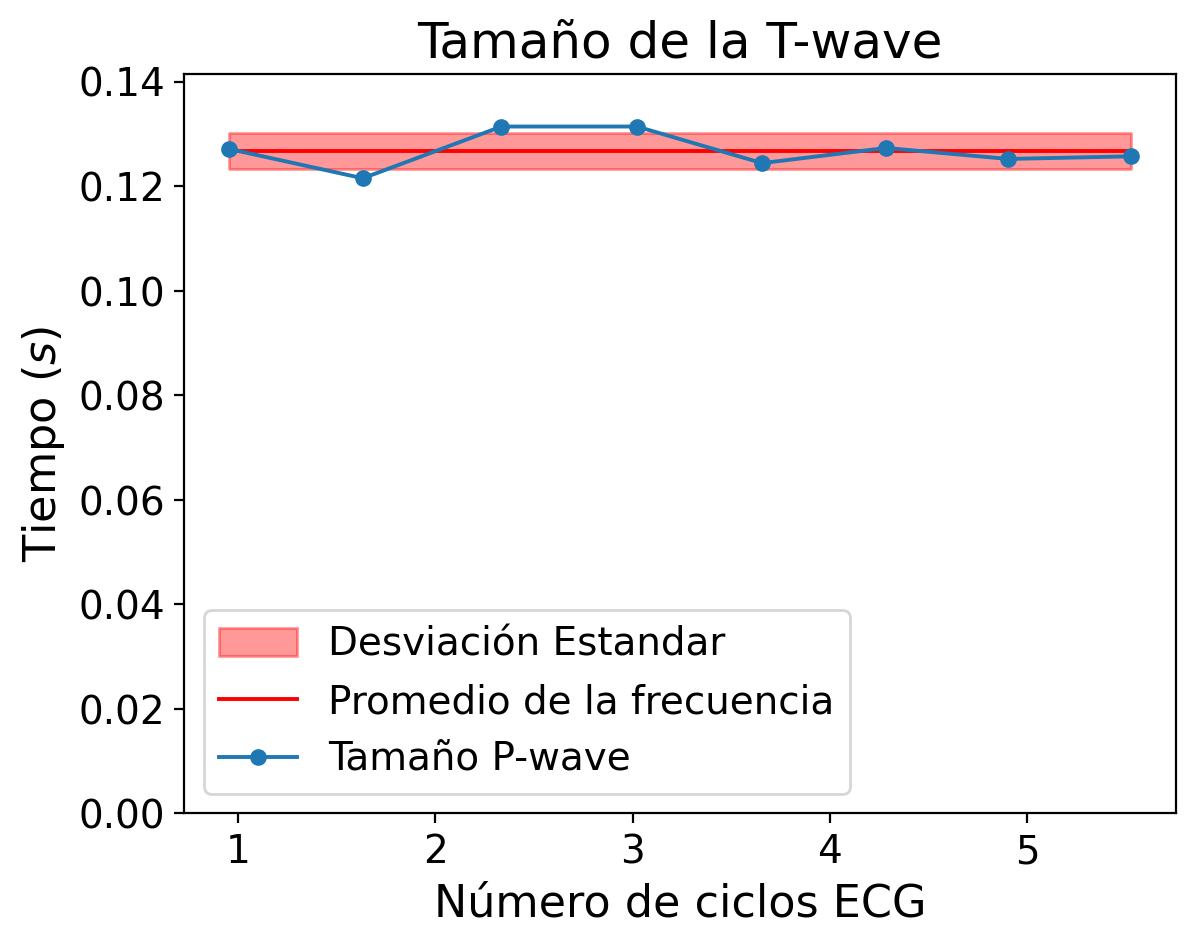

In [21]:
ECG_FR.Tamaño_Twave(mxs_indices=A,t_wave_begin=F[0], t_wave_end=F[1])